# Imports

## משאבים ורכיבי סימולציה

בסימולציה זו, 'המשאבים' מתייחסים למרכיבים השונים של הפסטיבל וכיצד הם מנוהלים. הקוד מחולק למספר קטגוריות עיקריות, שכל אחת מהן מגדירה סוגים שונים של ישויות ופעילויות בתוך הפסטיבל:

### 1. אלגוריתמי דגימה (`SamplingAlgorithms`)

זהו הבסיס לייצור אקראיות בסימולציה. המחלקה `SamplingAlgorithms` מכילה מתודות לדגימת ערכים מהתפלגויות שונות (למשל, אחידה, מעריכית, נורמלית, מולטינומית) וכן דגימות ספציפיות לאירועים כמו זמני הגעה של מבקרים, משכי שירות בתחנות, וזמני הופעות. אלגוריתמים אלו מבטיחים שההתנהגות של המבקרים והמערכת תהיה מציאותית ואקראית.

### 2. תורים (`Queue`)

מחלקה זו מדמה תורי המתנה לפעילויות שונות בפסטיבל. היא מטפלת בהוספה והוצאה של ישויות (מבקרים) מהתור, מתעדת זמני המתנה, עוקבת אחר אורך התור לאורך זמן, ומנהלת אירועי נטישה (כשמבקר מאבד סבלנות ועוזב את התור).

### 3. ישויות (`Entity`)

מחלקה אבסטרקטית זו מייצגת סוגים שונים של מבקרים בפסטיבל (בודדים, זוגות, קבוצות חברים). כל ישות עוקבת אחר:
*   **שביעות רצון**: מדד שמשתנה בהתאם לאירועים בפסטיבל.
*   **הוצאות**: כמה כסף המבקר הוציא.
*   **סבלנות**: משך הזמן שמבקר מוכן להמתין בתור לפני שינטוש.
*   **לוח פעילויות**: רשימת הפעילויות שהמבקר מתכנן לבצע.
*   **מצב**: האם המבקר סיים את כל פעילויותיו, אכל צהריים וכו'.

ישנם שלושה סוגי ישויות ספציפיים:
*   **`FriendsGroup`**: קבוצות של 3-6 חברים שמגיעים ביום הראשון, עשויים להישאר ליום השני, ומתכננים לראות הופעה מכל ז'אנר ולבקר בכל התחנות.
*   **`Couple`**: זוגות של 2 אנשים שמגיעים, מתחלפים בין הופעות לתחנות, ולא אוהבים מוזיקה אלקטרונית. הם עשויים להישאר ללילה אם שביעות הרצון שלהם גבוהה.
*   **`Single`**: מבקרים בודדים עם מסלול קבוע מראש (למשל, אוהל מרצ'נדייז, שתי הופעות מיינסטרים, שתי הופעות אינדי, הופעה אלקטרונית).

### 4. תחנות (`Station`)

מחלקה אבסטרקטית זו מייצגת פעילויות סטטיות בפסטיבל (כמו כניסה, תחנת צילום, עמדת טעינה). לכל תחנה יש:
*   **תור (`activity_queue`)**: לניהול המבקרים הממתינים.
*   **מספר משרתים (`num_servers`)**: קובע כמה מבקרים יכולים להיות מטופלים בו-זמנית.
*   **לוגיקת שירות**: איך נדגם זמן השירות וכיצד המבקרים מושפעים בסיום השירות.

דוגמאות לתחנות:
*   **`Entrance`**: כניסה לפסטיבל עם פקידים שסורקים כרטיסים ובודקים ביטחונית.
*   **`MerchTent`**: אוהל מרצ'נדייז עם קופאים, בו המבקרים רוכשים פריטים.
*   **`PhotoStation`**: תחנת צילום עם מספר עמדות, שבה המבקרים מצטלמים.
*   **`ChargingStation`**: עמדת טעינה לטלפונים עם מספר רב של מטענים.
*   **`BodyArt`**: עמדת קעקועי גוף עם אמנים, שבה מבקרים מקבלים ציורי גוף.

### 5. במות (`Stage`)

מחלקה אבסטרקטית זו מייצגת את הבמות השונות בפסטיבל (במה מרכזית, במת אינדי, במת DJ). לכל במה יש:
*   **ז'אנר (`genre`)**: סוג המוזיקה.
*   **קיבולת (`capacity`)**: מספר המבקרים שיכולים להיות בבמה בו-זמנית.
*   **הפסקות (`break_duration`)**: בין הופעות.
*   **לוגיקת שביעות רצון**: איך שביעות הרצון מושפעת מצפייה בהופעה.

דוגמאות לבמות:
*   **`MainStage`**: הבמה המרכזית עם הופעות מיינסטרים.
*   **`SideStage`**: במת האינדי.
*   **`DJStage`**: במת DJ עם מוזיקה אלקטרונית רציפה, פועלת באופן שונה מתחנה (ללא הפסקות או "הופעות" מוגדרות).

### 6. מסעדות (`Restaurant`)

מחלקה אבסטרקטית זו מייצגת דוכני מזון בפסטיבל. כל מסעדה היא גם תחנה (יורשת מ-`Station`) ויש לה:
*   **קופאי יחיד**: מטפל בהזמנות.
*   **זמן הכנה (`sample_prep_duration`)**: תלוי בסוג המסעדה.
*   **חישוב מחיר (`calculate_price`)**: תלוי בסוג המזון ובגודל הקבוצה.
*   **לוגיקת ארוחה גרועה**: הסתברות לאי שביעות רצון מהאוכל.

דוגמאות למסעדות:
*   **`Pizza`**: דוכן פיצה.
*   **`Burger`**: דוכן המבורגרים.
*   **`Asian`**: דוכן אוכל אסיאתי.

### 7. אירועים (`Event`)

מחלקה אבסטרקטית זו מהווה את הלב של מנוע הסימולציה. כל פעולה בסימולציה (הגעה, סיום שירות, סיום הופעה וכו') מוגדרת כאירוע. אירועים מתוזמנים לזמנים עתידיים ומאוחסנים בתור עדיפויות (heap), כך שהאירוע הקרוב ביותר תמיד מטופל קודם. ישנם סוגים רבים של אירועים, כגון:
*   **`ArrivalEvent`**: הגעה של מבקרים חדשים.
*   **`EndServiceEvent`**: סיום שירות בתחנה.
*   **`EndShowEvent`**: סיום הופעה בבמה.
*   **`AbandonEvent`**: מבקר נוטש תור.
*   **`EndOfDayEvent`**: סיום יום בפסטיבל.

### 8. פסטיבל (`Festival`)

מחלקה זו היא המכילה את כל רכיבי הסימולציה (תורים, ישויות, תחנות, במות, מסעדות) ואת המצב הנוכחי של הסימולציה (זמן, יום, הכנסות). היא אחראית על תיזמון אירועים וניהול המערכת כולה.

### 9. סימולטור (`Simulator`)

מחלקה זו מנהלת את לולאת האירועים הראשית של הסימולציה. היא מאתחלת את הסימולציה (קובעת אירועי הגעה ראשוניים, מתחילה הופעות), מריצה את האירועים לפי סדר הזמן, ובסיום מספקת דוחות וסיכומים על ביצועי הפסטיבל.

**לסיכום**, כל אחת מהמחלקות הללו מגדירה היבט ספציפי של הפסטיבל, וכולן יחד עובדות באופן משולב כדי לדמות את חווית המבקרים, תפעול המתקנים והאירועים בפסטיבל כולו.

In [ ]:
import random
import math
from collections import deque
from abc import ABC, abstractmethod
import heapq

#Sampling


<div dir="rtl" style="text-align: right; color: blue;">
חלק זה מתאר מנגנון דגימה שמאפשר להפיק ערכים אקראיים עבור המשתנים השונים במודל. המנגנון מבוסס על יצירת מספר אקראי אחיד בטווח [0,1], ולאחר מכן המרה שלו לערך שמתאים להתפלגות הרצויה. בשלב הראשון בנינו פונקציות כלליות להתפלגויות בסיסיות כמו אחידה רציפה, אחידה בדידה, ואקספוננציאלית, נורמלית. לאחר מכן השתמשנו בפונקציות האלו כדי להגדיר דגימות שמתאימות לכל משתנה בסימולציה, לפי הפרמטרים והאופי של אותו תהליך. במקרים שבהם היה צורך בהתפלגויות מורכבות יותר, כמו התפלגות קטגורית או פונקציית צפיפות מקטעית, יצרנו אלגוריתם דגימה מתאים. בצורה הזו התקבל מנגנון דגימה מסודר, עקבי ונוח לשימוש לאורך כל המודל.

$$
\mathbf{\Large \text{Calculating inverse transform for photo station duration}}
$$
</br>
$$
f_{\text{photo_station}}(X) =
\begin{cases}
\frac{X}{6} & \text{for } 1 \leq X < 2, \\
\frac{X}{5} + \frac{1}{8} & \text{for } 2 \leq X < 3, \\
\frac{1}{8} & \text{for } 3 \leq X < 4.
\end{cases}
$$
</br>
</br>  
$$
\text{Integral for } f_1(X) = \frac{X}{6} \text{ over the interval } [1, x]
$$
</br>   
$$
\int_1^t \frac{x}{6} \, dx = \frac{x^2 - 1}{12}
$$
</br>
$$
\text{This represents the result of the integral for the interval } 1 \leq x < 2.
$$
</br>
</br>
$$
\text{Integral for } f_2(X) = \frac{X}{5} + \frac{1}{8} \text{ over the interval } [2, x]
$$
</br>
$$
F(X=2) = \frac{x^2 - 1}{12} = \frac{2^2 -1}{12} = \frac{1}{4}
$$
</br>
$$
\frac{1}{4} + \int_2^t \left( \frac{x}{5} + \frac{1}{8} \right) dx
$$
</br>
$$
\\
\int_2^t \frac{x}{5} + \frac{1}{8} \, dx = \frac{1}{5} \left( \frac{x^2}{2} \right) + \frac{x}{8} \Bigg|_2^t = \frac{1}{10} \left( x^2 - 4 \right) + \frac{1}{8} (x - 2)
\\
$$
</br>
$$
\\
\frac{1}{4} + \left( \frac{x^2}{10} - \frac{4}{10}   + \frac{x}{8} - \frac{2}{8} \right)
$$
</br>
$$
 = \frac{x^2}{10} + \frac{x}{8} - 0.4
\\
$$
</br>
$$
This\ represents\ the\ result\ of\ th\ integral\ over\ the\ interval\ ( 2 \leq x < 3 ), where\ ( F(X=2) = \frac{1}{4} ) and\ the\ integral\ of\ the\ second\ part\ is\ computed.
$$
</br>  
$$
\text{Integral for } f_3(X) = \frac{1}{8} \text{ over the interval } [3, x]
$$
</br>
$$
F(X=3) = \frac{x^2}{10} + \frac{x}{8} - 0.4 =  \frac{3^2}{10} + \frac{3}{8} - 0.4 = \frac{7}{8}
$$
</br>   
$$
\frac{7}{8} + \int_3^t \frac{1}{8} \, dx = \left( \frac{x - 3}{8} \right) + \frac{7}{8} = \frac{x}{8} + \frac{1}{2}
$$
</br>
$$
\text{This represents the result of the integral for the interval } 3 \leq x < 4.
$$
</br>
</br>
$$
\text {Therefore}
$$
</br>
$$
F_{\text{photo_station}}(x)=
\begin{cases}
\frac{x^2 - 1}{12} & \text{for } 1 \leq X < 2, \\
\frac{x^2}{10} + \frac{x}{8} - 0.4  & \text{for } 2 \leq X < 3, \\
\frac{x}{8} + \frac{1}{2} &\text{for } 3 \leq X < 4.
\end{cases}
$$

</br>
</br>
$$
{First\ Determine\ the\ Ranges\ for\ ( u )}
$$
$$
1. For\ ( 1 \leq X < 2 ):
\\
F(X) = \frac{x^2 - 1}{12}, \quad U \in [0, F(2)] = [0, \frac{3}{12} = 0.25]
\\
$$
$$
2.\ For\ ( 2 \leq X < 3 ):
\\
F(X) = \frac{x^2}{10} + \frac{x}{8} - 0.4, \quad U \in [0.25, F(3)] = [0.25, 0.875]
\\
$$
$$
3.\ For\ ( 3 \leq X < 4 ):
\\
F(X) = \frac{x}{8} + \frac{1}{2}, \quad U \in [0.875, 1]
\\
$$
</br>
</br>
$$
{Seccond\ Equate\ F(x) to u}
$$
$$
1. For\ ( 1 \leq X < 2 ):
U = \frac{x^2 - 1}{12} \implies x^2 = 12U + 1 \implies x = \sqrt{12U + 1}
$$
$$
2.\ For\ (2 \leq x < 3):
F(x) = \frac{x^2}{10} + \frac{x}{8} - 0.4 = U  \Rightarrow \frac{x^2}{10} + \frac{x}{8} - \left( \frac{2}{5} + U \right) = 0
\Rightarrow x = \frac{-\frac{1}{8} \pm \sqrt{0.4U + 0.175625}}{0.2}
\text{Choose the positive root}
$$
$$
3.\ For\ ( 3 \leq X < 4 ):
U = \frac{x}{8} + \frac{1}{2} \implies x = 8(U - 0.5)
$$
</br>
</br>


$$
The\ inverse\ CDF\, ( F^{-1}(U) ),\ is:
$$

</br>
$$
\\
F_{\text{photo_station}}^{-1}(u) =
\begin{cases}
\sqrt{12u + 1} & \text{for } 0 \leq U < 0.25, \\
\frac{-\frac{1}{8} + \sqrt{0.4u + 0.175625}}{0.2} & \text{for } 0.25 \leq U < 0.875, \\
8(u - 0.5) & \text{for } 0.875 \leq U \leq 1
\end{cases}
\\
$$
</br>
$$
This\ function\ provides\ ( X )\ as\ a\ function\ of\ ( U ), where\ ( U \sim \text{Uniform}(0,1) ).
$$


$$
\mathbf{\Large \text{Calculating acceptance-rejection for DJ Stage duration}}
$$
</br>
The probability density function of the DJ Stage stay time is:

$$
f_{DJ}(x)=
\begin{cases}
\frac{x-20}{600}, & 20 < x \leq 40 \\
\frac{60-x}{600}+\frac{1}{30}, & 40 < x \leq 50 \\
\frac{60-x}{600}, & 50 < x \leq 60 \\
0, & \text{otherwise}
\end{cases}
$$

The support of the distribution is:

$$
20 \leq x \leq 60
$$

---

### Step 1: Find the maximum value of the density function

We need to find an upper bound \(T(x)\) such that:

$$
f_{DJ}(x) \leq T(x)
$$

for every \(x\) in the support.

We check the maximum value in each part of the piecewise function.

#### First interval: (20 < x < 40)

$$
f_{DJ}(x)=\frac{x-20}{600}
$$

This function is increasing, so the maximum is at \(x=40\):

$$
f_{DJ}(40)=\frac{40-20}{600}
=\frac{20}{600}
=\frac{1}{30}
$$

#### Second interval: \(40 < x < 50\)

$$
f_{DJ}(x)=\frac{60-x}{600}+\frac{1}{30}
$$

This function is decreasing, so the maximum is at \(x=40\):

$$
f_{DJ}(40)=\frac{60-40}{600}+\frac{1}{30}
=\frac{20}{600}+\frac{1}{30}
=\frac{1}{30}+\frac{1}{30}
=\frac{1}{15}
$$

#### Third interval: \(50 < x < 60\)

$$
f_{DJ}(x)=\frac{60-x}{600}
$$

This function is decreasing, so the maximum is at \(x=50\):

$$
f_{DJ}(50)=\frac{60-50}{600}
=\frac{10}{600}
=\frac{1}{60}
$$

Therefore, the overall maximum value is:

$$
f_{max}=\frac{1}{15}
$$

---

### Step 2: Define the envelope function

We choose a constant envelope function:

$$
T(x)=\frac{1}{15}
$$

for:

$$
20 \leq x \leq 60
$$

and:

$$
T(x)=0
$$

otherwise.

This envelope satisfies:

$$
f_{DJ}(x) \leq T(x)
$$

for every value of \(x\) in the support.

---

### Step 3: Normalize the envelope function

The proposal density is:

$$
r(x)=\frac{T(x)}{\int_{20}^{60}T(x)dx}
$$

First, calculate the integral of the envelope:

$$
\int_{20}^{60}\frac{1}{15}dx
=
\frac{1}{15}(60-20)
=
\frac{40}{15}
$$

Therefore:

$$
r(x)
=
\frac{\frac{1}{15}}{\frac{40}{15}}
=
\frac{1}{40}
$$

So the proposal distribution is:

$$
r(x) \sim U(20,60)
$$

This means that a candidate value can be generated by:

$$
X = 20 + 40U_1
$$

where:

$$
U_1 \sim U(0,1)
$$

---

### Step 4: Acceptance condition

After generating a candidate value \(X\), generate another random number:

$$
U_2 \sim U(0,1)
$$

The candidate value is accepted if:

$$
U_2 \leq \frac{f_{DJ}(X)}{T(X)}
$$

Since:

$$
T(X)=\frac{1}{15}
$$

the acceptance condition becomes:

$$
U_2 \leq \frac{f_{DJ}(X)}{\frac{1}{15}}
$$

If the condition is satisfied, we accept \(X\) as the generated DJ Stage stay time.

Otherwise, we reject \(X\) and repeat the process.

---

### Algorithm

1. Generate:

$$
U_1 \sim U(0,1)
$$

2. Generate a candidate value:

$$
X = 20 + 40U_1
$$

3. Generate:

$$
U_2 \sim U(0,1)
$$

4. Check the acceptance condition:

$$
U_2 \leq \frac{f_{DJ}(X)}{T(X)}
$$

5. If the condition holds, accept \(X\).

6. Otherwise, reject \(X\) and repeat the process.

The accepted value represents the generated stay time at the DJ Stage.

$$
\mathbf{\Large \text{Calculating inverse transform for phone charging station duration}}
$$
</br>

For the Phone Charging Station, we need to generate the charging time of a visitor's phone.

The process is divided into two stages:

1. Generate the visitor's battery level upon arrival.
2. Generate the required charging time based on that battery level.

---

## Step 1: Generate the battery level

The battery level upon arrival is normally distributed:

$$
B \sim N(40,15^2)
$$

where:

- \(B\) is the battery percentage upon arrival.
- The mean battery level is \(40\%\).
- The standard deviation is \(15\%\).

Since battery percentage must be within a feasible range, we use Acceptance-Rejection on the domain:

$$
0 \leq B < 100
$$

The algorithm is:

1. Generate:

$$
B \sim N(40,15^2)
$$

2. If:

$$
0 \leq B < 100
$$

accept \(B\).

3. Otherwise, reject \(B\) and generate a new value.

---

## Step 2: Calculate the parameter alpha

After accepting the battery level \(B=b\), we calculate:

$$
\alpha = \frac{100}{100-b}
$$

This parameter depends on the battery percentage upon arrival.

---

## Step 3: Define the charging time density function

The charging time density function is:

$$
f(t)=
\begin{cases}
\frac{\alpha}{40^\alpha}(40-t)^{\alpha-1}, & 0 \leq t \leq 40 \\
0, & \text{otherwise}
\end{cases}
$$

where:

- \(t\) is the charging time.
- \(b\) is the accepted battery percentage.
- (alpha) = 100/100-b\.

The support of the charging time is:

$$
0 \leq t \leq 40
$$

---

## Step 4: Find the CDF

To use the Inverse Transform Method, we first calculate the CDF:

$$
F(t)=\int_0^t \frac{\alpha}{40^\alpha}(40-s)^{\alpha-1}ds
$$

Using substitution, we get:

$$
F(t)=1-\left(\frac{40-t}{40}\right)^\alpha
$$

Therefore:

$$
F(t)=1-\left(1-\frac{t}{40}\right)^\alpha
$$

---

## Step 5: Apply the Inverse Transform Method

Let:

$$
U \sim U(0,1)
$$

Set:

$$
U = F(t)
$$

So:

$$
U = 1-\left(1-\frac{t}{40}\right)^\alpha
$$

Move terms:

$$
1-U = \left(1-\frac{t}{40}\right)^\alpha
$$

$$
(1-U)^{\frac{1}{\alpha}} = 1-\frac{t}{40}
$$

Therefore:

$$
t = 40\left(1-(1-U)^{\frac{1}{\alpha}}\right)
$$

Since \(1-U\) is also uniformly distributed, we can equivalently use:

$$
t = 40\left(1-U^{\frac{1}{\alpha}}\right)
$$

---

## Final algorithm

1. Generate a battery level:

$$
B \sim N(40,15^2)
$$

2. Accept \(B\) only if:

$$
0 \leq B < 100
$$

Otherwise, generate a new value.

3. Calculate:

$$
\alpha = \frac{100}{100-B}
$$

4. Generate:

$$
U \sim U(0,1)
$$

5. Generate the charging time:

$$
T = 40\left(1-U^{\frac{1}{\alpha}}\right)
$$

The generated value \(T\) represents the phone charging time.

## Code for sampling algorithms:

In [ ]:

class SamplingAlgorithms:

    # ── Primitives ────────────────────────────────────────────────────────────

    @staticmethod
    def uniform_continuous(low, high):
        """Sample from Continuous Uniform distribution using inverse transform."""
        u = random.random()
        return low + u * (high - low)

    @staticmethod
    def uniform_discrete(low, high):
        """Sample from Discrete Uniform distribution using inverse transform."""
        u = random.random()
        return math.floor(u * (high - low + 1)) + low

    @staticmethod
    def exponential(mean):
        """
        Exponential with given mean (= 1/lambda).
        Algorithm: Inverse Transform  =>  X = -mean * ln(U)
        Used for:
          - FriendsGroup inter-arrival   mean = 1.3712 min  (fitted, λ=0.7293)
          - Couple inter-arrival         mean = 1.0 min     (60/hr => 1/min)
          - Single inter-arrival         mean = 0.84 min    (500/day, window=420 min)
          - EntryGate security check     mean = 2 min
          - BodyArt neon drawing         mean = 12 min
        """
        u = 1- random.random()
        return -mean * math.log(u)

    @staticmethod
    def bernoulli(p):
        """Sample from Bernoulli distribution using inverse transform."""
        u = random.random()
        return u < p

    @staticmethod
    def multinomial(probabilities):
        """
        Sample from Multinomial distribution using inverse transform.
        Returns index of chosen category.
        """
        u = random.random()
        cumulative = 0
        for i, p in enumerate(probabilities):
            cumulative += p
            if u < cumulative:
                return i
        return len(probabilities) - 1  # fallback for floating-point errors

    @staticmethod
    def normal(mu, sigma):
        """
        Sample from Normal distribution using Box-Muller transform.
        Used for:
          - MainStage concert duration   μ=45.90, σ=8.93  (fitted to data)
          - BodyArt glitter duration     μ=15,    σ=3
          - ChargingStation battery %    μ=40,    σ=15
          - Food cashier service time    μ=5,     σ=1.5
        """
        u1 = 1 - random.random()   # avoid log(0)
        u2 = random.random()
        z = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)
        return mu + sigma * z

    # ── Arrivals ──────────────────────────────────────────────────────────────

    @staticmethod
    def friends_arrival():
        """
        Inter-arrival time for FriendsGroup (minutes).
        Fitted: Exponential, λ=0.7293 (MLE from data)  =>  mean ≈ 1.37 min.
        Algorithm: Inverse Transform
        """
        return SamplingAlgorithms.exponential(1 / 0.7293)

    @staticmethod
    def couple_arrival():
        """
        Inter-arrival time for Couple (minutes).
        Given: Exponential, mean = 1 min  (rate = 60 arrivals/hr).
        Algorithm: Inverse Transform
        """
        return SamplingAlgorithms.exponential(1.0)

    @staticmethod
    def single_arrival():
        """
        Inter-arrival time for Single visitor (minutes).
        Given: Exponential, mean = 420/500 = 0.84 min
               (500 arrivals over 420-minute window 09:00–16:00).
        Algorithm: Inverse Transform
        """
        return SamplingAlgorithms.exponential(420 / 500)

    # ── Entry Gate ────────────────────────────────────────────────────────────

    @staticmethod
    def entry_scan_duration():
        """
        Ticket scan duration at entrance (minutes).
        Distribution: Continuous Uniform [1.5, 3]
        Algorithm: Inverse Transform
        """
        return SamplingAlgorithms.uniform_continuous(1.5, 3.0)

    @staticmethod
    def entry_security_duration():
        """
        Security check duration at entrance (minutes).
        Distribution: Exponential, mean = 2 min.
        Algorithm: Inverse Transform
        """
        return SamplingAlgorithms.exponential(2.0)

    # ── Stages ────────────────────────────────────────────────────────────────

    @staticmethod
    def main_stage_duration():
        """
        MainStage (mainstream) show duration (minutes).
        Fitted: Normal, μ=45.90 min, σ=8.93 min (MLE from data).
        Algorithm: Box-Muller (reuses normal())
        """
        return SamplingAlgorithms.normal(45.90, 8.93)

    @staticmethod
    def side_stage_duration():
        """
        SideStage (indie) show duration (minutes).
        Distribution: Continuous Uniform [20, 30]
        Algorithm: Inverse Transform
        """
        return SamplingAlgorithms.uniform_continuous(20.0, 30.0)

    @staticmethod
    def dj_stage_duration():
        """
        DJ-stage stay duration (minutes).

        PDF (3-piece, support [20, 60]):
          f(x) = (x-20)/600,           20 <= x <= 40
          f(x) = (60-x)/600 + 1/30,    40 <= x <= 50
          f(x) = (60-x)/600,           50 <= x <= 60

        Algorithm: Rejection-Acceptance
          Proposal:  g(x) = Uniform(20, 60)  =>  g(x) = 1/40
          f_max:     f(40) = 20/600 + 1/30 = 1/15
          Envelope:  c = f_max / g(x) = (1/15) / (1/40) = 8/3
          Accept if: U <= f(Y) / (c * g(Y)) = f(Y) * 15
        """
        C         = 8.0 / 3.0
        g_density = 1.0 / 40.0

        while True:
            y = SamplingAlgorithms.uniform_continuous(20.0, 60.0)
            u = random.random()

            if 20.0 <= y <= 40.0:
                f_y = (y - 20.0) / 600.0
            elif 40.0 < y <= 50.0:
                f_y = (60.0 - y) / 600.0 + 1.0 / 30.0
            elif 50.0 < y <= 60.0:
                f_y = (60.0 - y) / 600.0
            else:
                f_y = 0.0

            if u <= f_y / (C * g_density):
                return y

    # ── Stations ──────────────────────────────────────────────────────────────

    @staticmethod
    def photo_duration():
        """
        Photo session duration (minutes).

        PDF (3-piece, support [1, 4]):
          f(x) = x/6,         1 <= x < 2   (weight p1 = 1/4)
          f(x) = x/5 + 1/8,   2 <= x < 3   (weight p2 = 5/8)
          f(x) = 1/8,         3 <= x < 4   (weight p3 = 1/8)

        Algorithm: Composition
          Inverse transforms:
            Piece 1:  x = sqrt(3u + 1)
            Piece 2:  x = sqrt(400u + 441)/8 - 5/8
            Piece 3:  x = 3 + u
        """
        u1 = random.random()

        if u1 < 0.25:
            u2 = random.random()
            return math.sqrt(3.0 * u2 + 1.0)
        elif u1 < 0.875:
            u2 = random.random()
            return math.sqrt(400.0 * u2 + 441.0) / 8.0 - 5.0 / 8.0
        else:
            u2 = random.random()
            return 3.0 + u2

    @staticmethod
    def charging_duration(battery_pct):
        """
        Charging duration (minutes) given battery % on arrival.
        Distribution: Power-law CDF, α = 100 / (100 - battery_pct).
        Algorithm: Inverse Transform  =>  t = 40 - 40*(1-U)^(1/α)
        """
        battery_pct = max(0.0, min(99.0, battery_pct))
        alpha = 100.0 / (100.0 - battery_pct)
        u = random.random()
        return 40.0 - 40.0 * ((1.0 - u) ** (1.0 / alpha))

    @staticmethod
    def sample_charging_station():
        """
        Sample battery % on arrival (Normal) and charging duration.
        Returns (battery_pct, duration).
        """
        b = SamplingAlgorithms.normal(40.0, 15.0)
        b = max(0.0, min(99.0, b))
        return b, SamplingAlgorithms.charging_duration(b)

    @staticmethod
    def merch_purchase_duration():
        """
        Service time at MerchTent per entity (minutes).
        Distribution: Continuous Uniform [2, 6]
        Algorithm: Inverse Transform
        """
        return SamplingAlgorithms.uniform_continuous(2.0, 6.0)

    @staticmethod
    def body_art_duration(art_type: str):
        """
        Body-art session duration (minutes) by type.
          'glitter'  → Normal(μ=15, σ=3)          — Box-Muller
          'neon'     → Exponential(mean=12)         — Inverse Transform
          'henna'    → Continuous Uniform [17, 22]  — Inverse Transform
        """
        if art_type == "glitter":
            return SamplingAlgorithms.normal(15.0, 3.0)
        elif art_type == "neon":
            return SamplingAlgorithms.exponential(12.0)
        elif art_type == "henna":
            return SamplingAlgorithms.uniform_continuous(17.0, 22.0)
        else:
            raise ValueError(f"Unknown art_type: {art_type!r}")

    # ── Food Stalls ───────────────────────────────────────────────────────────

    @staticmethod
    def food_service_duration():
        """
        Cashier service time at any food stall (minutes).
        Distribution: Normal(μ=5, σ=1.5)
        Algorithm: Box-Muller
        """
        return SamplingAlgorithms.normal(5.0, 1.5)

    @staticmethod
    def food_prep_duration(stall: str):
        """
        Food preparation time per entity order (minutes).
          'pizza'   → Uniform [4, 6]
          'burger'  → Uniform [3, 4]
          'asian'   → Uniform [3, 7]
        """
        ranges = {"pizza": (4.0, 6.0), "burger": (3.0, 4.0), "asian": (3.0, 7.0)}
        if stall not in ranges:
            raise ValueError(f"Unknown stall: {stall!r}")
        return SamplingAlgorithms.uniform_continuous(*ranges[stall])

    @staticmethod
    def food_eating_duration():
        """
        Eating + return-to-festival time per entity (minutes).
        Distribution: Continuous Uniform [15, 35]
        Algorithm: Inverse Transform
        """
        return SamplingAlgorithms.uniform_continuous(15.0, 35.0)

    @staticmethod
    def choose_restaurant() -> str:
        """
        Restaurant selection by visitor preference.
        Distribution: 3/8 burger, 1/4 pizza, 3/8 asian.
        Algorithm: Multinomial (inverse transform)
        """
        idx = SamplingAlgorithms.multinomial([3.0/8, 1.0/4, 3.0/8])
        return ["burger", "pizza", "asian"][idx]


#Distribution Fitting

<div dir="rtl">


### FriendsGroup Arrival Intervals ← התפלגות מעריכית (Exponential)

**היגיון תיאורטי:**
זמני הגעה בין קבוצות הם תהליך אקראי ללא זיכרון — הזמן עד ההגעה הבאה אינו תלוי בכמה זמן כבר עבר.

**הנתונים:**
ממוצע = 1.37, סטיית תקן = 1.19  

סטיית התקן ≈ ממוצע- זהו סימן קלאסי של התפלגות מעריכית שבה $\sigma = \mu = \frac{1}{\lambda}$.


---

### MainStage Concert Duration ← התפלגות נורמלית (Normal)

**הנתונים:**
הממוצע (45.9) נמצא באמצע הטווח (22.6 עד 65.8), וסטיית התקן קטנה יחסית לממוצע (פחות מ־20%)  הנתונים מרוכזים סביב מרכז ברור.

---
**נעשה ניתוח התפלגות ונבחן זאת לאחר מכן באמצעות מבחן KS**

</div>

Saving samples_for_simulation (2).xlsx to samples_for_simulation (2) (1).xlsx



  FriendsGroup_arrival_intervals  |  Exponential
  Observations : 100
  Mean         : 1.3712
  Std Dev      : 1.1937
  Min / Max    : 0.0271 / 5.5431
  Distribution : Exponential
  MLE params   : λ (MLE) = 0.7293  →  mean = 1.3712 min
  KS statistic : 0.0885
  KS p-value   : 0.3914
  Verdict      : ✓ Cannot reject fit (p ≥ 0.05)


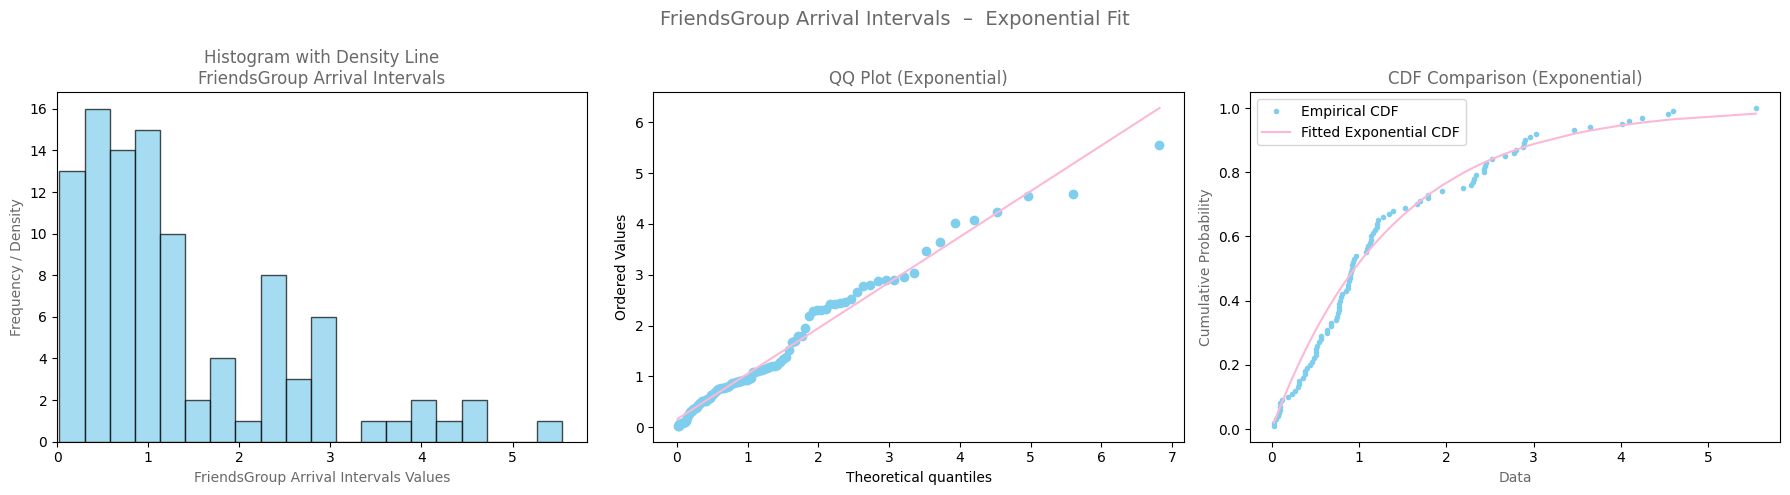


  MainStage_concert_duration  |  Normal
  Observations : 100
  Mean         : 45.9028
  Std Dev      : 8.9724
  Min / Max    : 22.6461 / 65.8454
  Distribution : Normal
  MLE params   : μ (MLE) = 45.9028,  σ (MLE) = 8.9274
  KS statistic : 0.1024
  KS p-value   : 0.2290
  Verdict      : ✓ Cannot reject fit (p ≥ 0.05)


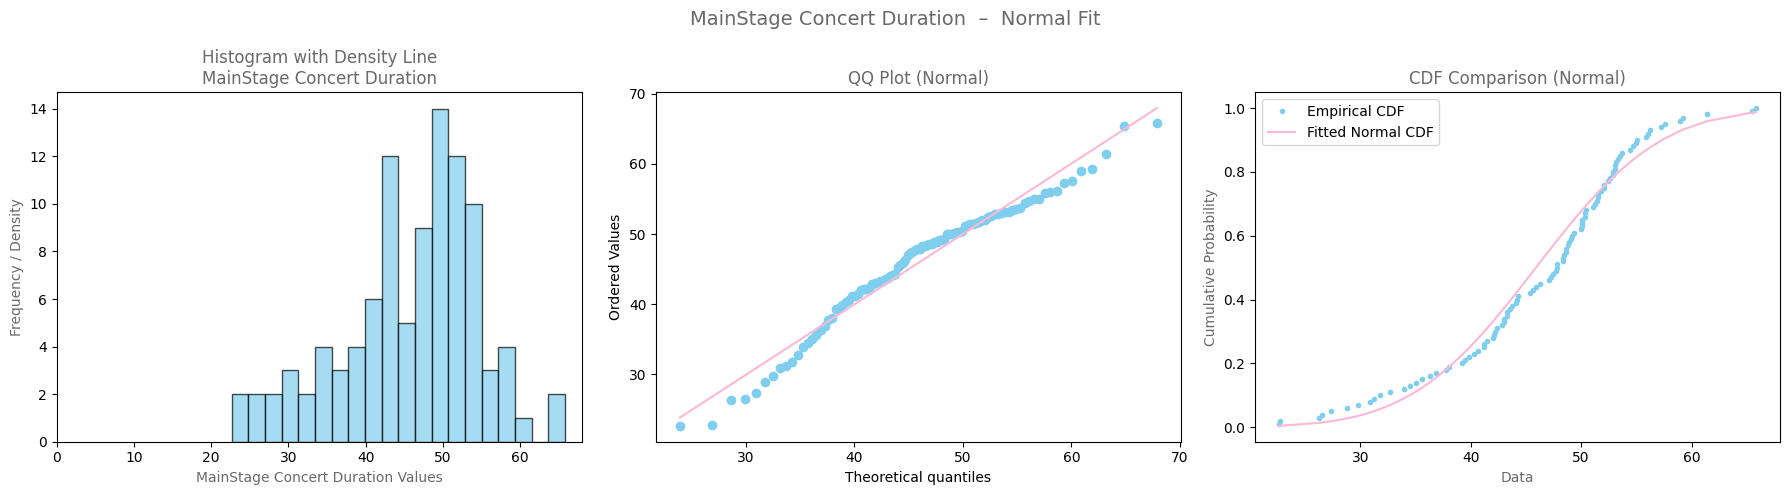

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import probplot, kstest, expon, norm, lognorm
from scipy.optimize import minimize
from IPython.display import display, HTML

# ── Load data ──────────────────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()
excel_file = list(uploaded.keys())[0]
sheets = pd.read_excel(excel_file, sheet_name=None)

SHEET_CONCERT   = "MainStage_concert_duration"
SHEET_FRIENDS   = "FriendsGroup_arrival_intervals"
COLUMN          = "minutes"

unified_blue = "#80CEED"
unified_pink = "#FCB8D6"


# ── Helper functions ───────────────────────────────────────────────────────────

def read_column_data(sheet_name, column_name=COLUMN):
    return sheets[sheet_name][column_name].dropna()


def histogram_and_density_line(data, column_name, ax):
    ax.hist(data, bins=20, edgecolor="black", alpha=0.7,
            label="Histogram", color=unified_blue)
    ax.set_title(f"Histogram with Density Line\n{column_name}", color="dimgray")
    ax.set_xlabel(f"{column_name} Values", color="dimgray")
    ax.set_ylabel("Frequency / Density", color="dimgray")
    ax.set_xlim(left=0)


def MLE_for_lambda(data):
    """MLE estimate of λ for an Exponential distribution."""
    def neg_log_likelihood(lambda_, data):
        return -np.sum(np.log(lambda_) - lambda_ * data)
    lambda_mle = 1 / np.mean(data)
    result = minimize(neg_log_likelihood, lambda_mle,
                      args=(data,), bounds=[(0.0001, None)])
    return result.x[0]


def MLE_for_normal(data):
    """MLE estimates of μ and σ for a Normal distribution."""
    mu    = np.mean(data)
    sigma = np.std(data, ddof=0)          # MLE uses ddof=0
    return mu, sigma


def QQ_plot_expon(data, lambda_mle, ax):
    probplot(data, dist="expon", sparams=(0, 1 / lambda_mle), plot=ax)
    ax.get_lines()[0].set_color(unified_blue)
    ax.get_lines()[1].set_color(unified_pink)
    ax.set_title("QQ Plot (Exponential)", color="dimgray")


def QQ_plot_normal(data, mu, sigma, ax):
    probplot(data, dist="norm", sparams=(mu, sigma), plot=ax)
    ax.get_lines()[0].set_color(unified_blue)
    ax.get_lines()[1].set_color(unified_pink)
    ax.set_title("QQ Plot (Normal)", color="dimgray")


def CDF_plot_expon(data, lambda_mle, ax):
    sorted_data = np.sort(data)
    emp_cdf     = np.arange(1, len(data) + 1) / len(data)
    fit_cdf      = 1 - np.exp(-lambda_mle * sorted_data)
    ax.plot(sorted_data, emp_cdf,  "o", markersize=3,
            label="Empirical CDF",         color=unified_blue)
    ax.plot(sorted_data, fit_cdf,  "-",
            label="Fitted Exponential CDF", color=unified_pink)
    ax.set_title("CDF Comparison (Exponential)", color="dimgray")
    ax.set_xlabel("Data", color="dimgray")
    ax.set_ylabel("Cumulative Probability", color="dimgray")
    ax.legend(loc="upper left")


def CDF_plot_normal(data, mu, sigma, ax):
    sorted_data = np.sort(data)
    emp_cdf     = np.arange(1, len(data) + 1) / len(data)
    fit_cdf     = norm.cdf(sorted_data, loc=mu, scale=sigma)
    ax.plot(sorted_data, emp_cdf,  "o", markersize=3,
            label="Empirical CDF",    color=unified_blue)
    ax.plot(sorted_data, fit_cdf,  "-",
            label="Fitted Normal CDF", color=unified_pink)
    ax.set_title("CDF Comparison (Normal)", color="dimgray")
    ax.set_xlabel("Data", color="dimgray")
    ax.set_ylabel("Cumulative Probability", color="dimgray")
    ax.legend(loc="upper left")


def ks_test_expon(data, lambda_mle):
    stat, p = kstest(data, "expon", args=(0, 1 / lambda_mle))
    return stat, p


def ks_test_normal(data, mu, sigma):
    stat, p = kstest(data, "norm", args=(mu, sigma))
    return stat, p


def print_stats_summary(label, data, dist_name, params, ks_stat, ks_p):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Observations : {len(data)}")
    print(f"  Mean         : {np.mean(data):.4f}")
    print(f"  Std Dev      : {np.std(data, ddof=1):.4f}")
    print(f"  Min / Max    : {data.min():.4f} / {data.max():.4f}")
    print(f"  Distribution : {dist_name}")
    print(f"  MLE params   : {params}")
    print(f"  KS statistic : {ks_stat:.4f}")
    print(f"  KS p-value   : {ks_p:.4f}")
    verdict = "✓ Cannot reject fit (p ≥ 0.05)" if ks_p >= 0.05 else "✗ Reject fit (p < 0.05)"
    print(f"  Verdict      : {verdict}")
    print(f"{'='*55}")


# ══════════════════════════════════════════════════════════════════════════════
# 1.  FriendsGroup_arrival_intervals  →  Exponential
# ══════════════════════════════════════════════════════════════════════════════

display(HTML("<h1 style='text-align:center; color:#FCB8D6;'>"
             "FriendsGroup Arrival Intervals – Graphical Comparison</h1>"))

data_friends   = read_column_data(SHEET_FRIENDS)
lambda_friends = MLE_for_lambda(data_friends)
ks_stat_f, ks_p_f = ks_test_expon(data_friends, lambda_friends)

print_stats_summary(
    label     = "FriendsGroup_arrival_intervals  |  Exponential",
    data      = data_friends,
    dist_name = "Exponential",
    params    = f"λ (MLE) = {lambda_friends:.4f}  →  mean = {1/lambda_friends:.4f} min",
    ks_stat   = ks_stat_f,
    ks_p      = ks_p_f,
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
histogram_and_density_line(data_friends, "FriendsGroup Arrival Intervals", axs[0])
QQ_plot_expon(data_friends, lambda_friends, axs[1])
CDF_plot_expon(data_friends, lambda_friends, axs[2])
plt.suptitle("FriendsGroup Arrival Intervals  –  Exponential Fit",
             color="dimgray", fontsize=14)
plt.tight_layout()
plt.savefig("friends_arrival_stats.png", dpi=150, bbox_inches="tight")
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# 2.  MainStage_concert_duration  →  Normal
# ══════════════════════════════════════════════════════════════════════════════

display(HTML("<h1 style='text-align:center; color:#FCB8D6;'>"
             "MainStage Concert Duration – Graphical Comparison</h1>"))

data_concert        = read_column_data(SHEET_CONCERT)
mu_concert, sigma_concert = MLE_for_normal(data_concert)
ks_stat_c, ks_p_c   = ks_test_normal(data_concert, mu_concert, sigma_concert)

print_stats_summary(
    label     = "MainStage_concert_duration  |  Normal",
    data      = data_concert,
    dist_name = "Normal",
    params    = f"μ (MLE) = {mu_concert:.4f},  σ (MLE) = {sigma_concert:.4f}",
    ks_stat   = ks_stat_c,
    ks_p      = ks_p_c,
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
histogram_and_density_line(data_concert, "MainStage Concert Duration", axs[0])
QQ_plot_normal(data_concert, mu_concert, sigma_concert, axs[1])
CDF_plot_normal(data_concert, mu_concert, sigma_concert, axs[2])
plt.suptitle("MainStage Concert Duration  –  Normal Fit",
             color="dimgray", fontsize=14)
plt.tight_layout()
plt.savefig("mainstage_duration_stats.png", dpi=150, bbox_inches="tight")
plt.show()

<div dir="rtl">

---

## ניתוח התפלגות עבור: FriendsGroup Arrival Intervals (מרווחי הגעה)

---

### היסטוגרמה
בניתוח מרווחי ההגעה של קבוצות חברים, ההיסטוגרמה מציגה דפוס מובהק של התפלגות מעריכית (אקספוננציאלית). ניתן לזהות ריכוז גבוה מאוד של תצפיות בערכים הנמוכים (סביב 0 עד 1.5 דקות), כאשר התדירות פוחתת בצורה חדה ככל שהערכים עולים. תבנית זו מאפיינת זמני המתנה או מרווחי זמן, בהם רוב האירועים קורים בסמיכות, אך קיימים זנבות ארוכים המייצגים זמני הגעה ארוכים נדירים יותר.

---

### QQ Plot
ניתן לראות התאמה טובה מאוד של הנתונים האמפיריים לקו התיאורטי הוורוד. מרבית הנקודות מונחות ישירות על הקו. קיימת סטייה קלה בלבד בערכים הקיצוניים ביותר (הנקודות העליונות בזנב הימני), אך אין בכך כדי לפסול את ההתאמה הכוללת של המודל למרבית הנתונים.

---

### התאמה לפונקציה המצטברת (CDF)
בהשוואה בין ההתפלגות האמפירית (הנקודות התכולות) לפונקציה המצטברת (הקו הוורוד), ניכרת התאמה הדוקה מאוד לאורך כל הטווח. קצב הצטברות הנתונים תואם כמעט בשלמותו לקצב המצופה מהמודל האקספוננציאלי התיאורטי.

---

### סיכום
הכלים הגרפיים מצביעים על התאמה גבוהה להתפלגות מעריכית. נתון זה נתמך סטטיסטית על ידי מבחן קולמוגורוב-סמירנוב (KS) שבו ה-p-value הוא $0.3914$. מכיוון שהערך גדול מ-$0.05$, לא ניתן לדחות את השערת האפס, ואנו מסיקים כי מרווחי ההגעה אכן מתפלגים מעריכית עם תוחלת של $1.3712$ דקות.

---

### מציאת פרמטר לפי MLE — התפלגות מעריכית

פונקציית צפיפות ההסתברות:
$$f(x;\lambda) = \begin{cases} \lambda e^{-\lambda x} & x \ge 0 \\ 0 & x < 0 \end{cases}$$

פונקציית הסבירות (Likelihood) בהינתן מדגם בגודל $n$:
$$L(\lambda) = \prod_{i=1}^{n} \lambda e^{-\lambda x_i} = \lambda^n e^{-\lambda \sum_{i=1}^{n} x_i}$$

פונקציית הלוג-סבירות (Log-Likelihood):
$$\ell(\lambda) = \ln L(\lambda) = n \ln(\lambda) - \lambda \sum_{i=1}^{n} x_i$$

נגזור לפי $\lambda$ ונשווה לאפס:
$$\frac{d\ell(\lambda)}{d\lambda} = \frac{n}{\lambda} - \sum_{i=1}^{n} x_i = 0$$

נבודד את $\lambda$:
$$\lambda = \frac{n}{\sum_{i=1}^{n} x_i} = \frac{1}{\bar{x}}$$

**מסקנה:** אומדן הסבירות המרבית של $\lambda$ הוא $\hat{\lambda}_{MLE} = \frac{1}{\bar{x}}$.
עבור הנתונים, הממוצע הוא $1.3712$, ולכן:
$$\hat{\lambda}_{MLE} = \frac{1}{1.3712} \approx 0.7293$$

---
---

## ניתוח התפלגות עבור: MainStage Concert Duration (משך הופעה בבמה המרכזית)

---

### היסטוגרמה
בניתוח משך ההופעות, ההיסטוגרמה מציגה דפוס פעמוני וסימטרי יחסית סביב הממוצע (אזור ה-45 דקות). השכיחות הגבוהה ביותר מתרכזת במרכז, והיא הולכת ופוחתת בצורה דומה לשני הכיוונים. תבנית זו היא המאפיין הקלאסי של התפלגות נורמלית.

---

### QQ Plot
הנקודות האמפיריות מיושרות בצורה מצוינת לאורך הקו האלכסוני של ההתפלגות התיאורטית מזווית לזווית. התאמה כזו גם במרכז וגם בזנבות מהווה אינדיקציה חזקה מאוד לכך שהנתונים הגיעו מאוכלוסייה המתפלגת נורמלית.

---

### התאמה לפונקציה המצטברת (CDF)
העקומה מציגה צורת S מובהקת (Sigmoid) האופיינית לפונקציה המצטברת של התפלגות נורמלית. הנקודות האמפיריות עוקבות בדיוק רב אחרי העקומה התיאורטית לכל אורך הטווח.

---

### סיכום
הניתוח הגרפי מעיד בצורה חד-משמעית על התאמה להתפלגות נורמלית. גם כאן, מבחן ה-KS תומך בכך עם p-value של $0.2290$ (גדול מ-$0.05$), ולכן איננו דוחים את השערת האפס לפיה משך ההופעות מתפלג נורמלית עם ממוצע של $45.9$ וסטיית תקן של כ-$8.9$.

---

### מציאת פרמטרים לפי MLE — התפלגות נורמלית

פונקציית צפיפות ההסתברות:
$$f(x;\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

פונקציית הסבירות (Likelihood):
$$L(\mu,\sigma^2) = (2\pi\sigma^2)^{-\frac{n}{2}} e^{-\frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2}$$

פונקציית הלוג-סבירות (Log-Likelihood):
$$\ell(\mu,\sigma^2) = -\frac{n}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2$$

**מציאת התוחלת** — נגזור לפי $\mu$ ונשווה לאפס:
$$\frac{\partial\ell}{\partial\mu} = \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i-\mu) = 0 \implies \hat{\mu}_{MLE} = \bar{x}$$

**מציאת השונות** — נגזור לפי $\sigma^2$ ונשווה לאפס:
$$\frac{\partial\ell}{\partial\sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{i=1}^{n}(x_i-\mu)^2 = 0 \implies \hat{\sigma}^2_{MLE} = \frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2$$

**מסקנה:** אומדני ה-MLE עבור התפלגות נורמלית הם ממוצע המדגם ושונות המדגם, התואמים בדיוק לערכים שהתקבלו:
$$\hat{\mu}_{MLE} = 45.9028 \quad , \quad \hat{\sigma}_{MLE} = 8.9274$$

</div>

In [ ]:
import numpy as np
from IPython.display import display, HTML

# ══════════════════════════════════════════════════════════════════════════════
# Goodness-of-Fit Test (KS)
# FriendsGroup_arrival_intervals  → Exponential
# MainStage_concert_duration      → Normal
# ══════════════════════════════════════════════════════════════════════════════

# ── Empirical CDF ──────────────────────────────────────────────────────────────
def empirical_cdf(data):
    data_sorted = np.sort(data)
    n = len(data)
    return data_sorted, np.arange(1, n + 1) / n


# ── Modified KS statistic (Kolmogorov's formula with finite-sample correction) ─
def ks_test(data, cdf_func, dist_name, *params):
    n = len(data)
    data_sorted, empirical_cdf_values = empirical_cdf(data)
    theoretical_cdf_values = cdf_func(data_sorted, *params)

    # חישוב סטטיסטי ה-D הבסיסי
    d_statistic = np.max(np.abs(empirical_cdf_values - theoretical_cdf_values))

    # הפעלת נוסחת התיקון (Stephens Modification) בהתאם להתפלגות
    if dist_name == "Exponential":
        new_d_statistic = (np.sqrt(n) + 0.26 + (0.25 / np.sqrt(n))) * (d_statistic - 0.2 / n)
    elif dist_name == "Normal":
        # נוסחת התיקון למבחן נורמלי (Lilliefors / Stephens)
        new_d_statistic = d_statistic * (np.sqrt(n) - 0.01 + 0.85 / np.sqrt(n))
    else:
        new_d_statistic = d_statistic

    return new_d_statistic


# ── Theoretical CDFs ───────────────────────────────────────────────────────────
def exp_cdf(x, lambda_):
    return 1 - np.exp(-lambda_ * x)

def normal_cdf(x, mu, sigma):
    from scipy.stats import norm as scipy_norm
    return scipy_norm.cdf(x, loc=mu, scale=sigma)


# ── Critical value table (Kolmogorov / Stephens) ──────────────────────────────
def d_critical(alpha, dist_name):
    if dist_name == "Exponential":
        table = {0.15: 0.926, 0.10: 1.022, 0.05: 1.094, 0.025: 1.190, 0.01: 1.308}
    elif dist_name == "Normal":
        # טבלה מעודכנת עבור התפלגות נורמלית שבה הפרמטרים נאמדו מתוך המדגם
        table = {0.15: 0.775, 0.10: 0.819, 0.05: 0.886, 0.025: 0.949, 0.01: 1.031}
    else:
        return None

    return table.get(alpha, None)


# ── Hypothesis test conclusion ─────────────────────────────────────────────────
# הוספנו את הפרמטר alpha כדי שההדפסה תהיה מדויקת בכל הרצה
def hypothesis_test(critical_value, d_statistic, dist_name, alpha):
    if d_statistic > critical_value:
        print(f"  D Statistic   : {d_statistic:.4f}")
        print(f"  Critical Value: {critical_value}")
        print(f"  {d_statistic:.4f} > {critical_value}  →  Reject H₀")
        print(f"  ✗ The data does NOT follow a {dist_name} distribution (α = {alpha})")
    else:
        print(f"  D Statistic   : {d_statistic:.4f}")
        print(f"  Critical Value: {critical_value}")
        print(f"  {d_statistic:.4f} < {critical_value}  →  Fail to reject H₀")
        print(f"  ✓ The data follows a {dist_name} distribution (α = {alpha})")


# ══════════════════════════════════════════════════════════════════════════════
# 1. FriendsGroup_arrival_intervals  →  Exponential (α = 0.05)
# ══════════════════════════════════════════════════════════════════════════════
display(HTML("<h2 style='text-align:left; color:orange;'>"
             "FriendsGroup Arrival Intervals — KS Test (Exponential)</h2>"))

d_stat_friends = ks_test(data_friends, exp_cdf, "Exponential", lambda_friends)
cv_friends_05 = d_critical(0.05, "Exponential")
print("--- Testing at α = 0.05 ---")
hypothesis_test(cv_friends_05, d_stat_friends, "Exponential", 0.05)


# ══════════════════════════════════════════════════════════════════════════════
# 2. MainStage_concert_duration  →  Normal (α = 0.05 AND α = 0.025)
# ══════════════════════════════════════════════════════════════════════════════
display(HTML("<h2 style='text-align:left; color:orange;'>"
             "MainStage Concert Duration — KS Test (Normal)</h2>"))

d_stat_concert = ks_test(data_concert, normal_cdf, "Normal", mu_concert, sigma_concert)

# הרצה ראשונה: רמת מובהקות של 5%
print("--- Testing at α = 0.05 ---")
cv_concert_05 = d_critical(0.05, "Normal")
hypothesis_test(cv_concert_05, d_stat_concert, "Normal", 0.05)

# הרצה שנייה: רמת מובהקות של 2.5%
print("\n--- Testing at α = 0.025 ---")
cv_concert_025 = d_critical(0.025, "Normal")
hypothesis_test(cv_concert_025, d_stat_concert, "Normal", 0.025)

--- Testing at α = 0.05 ---
  D Statistic   : 0.7865
  Critical Value: 1.094
  0.7865 < 1.094  →  Fail to reject H₀
  ✓ The data follows a Exponential distribution (α = 0.05)


--- Testing at α = 0.05 ---
  D Statistic   : 0.9309
  Critical Value: 0.886
  0.9309 > 0.886  →  Reject H₀
  ✗ The data does NOT follow a Normal distribution (α = 0.05)

--- Testing at α = 0.025 ---
  D Statistic   : 0.9309
  Critical Value: 0.949
  0.9309 < 0.949  →  Fail to reject H₀
  ✓ The data follows a Normal distribution (α = 0.025)


<div dir="rtl">


### אישוש התפלגות באמצעות מבחן Kolmogorov-Smirnov (KS)

בהתבסס על תוצאות מבחן KS, נבדקה התאמה של הנתונים להתפלגויות התיאורטיות שנבחרו עבור הסימולציה.

**תוצאות עבור FriendsGroup Arrival Intervals:**
* **סטטיסטיקת המבחן:** $D = 0.7865$
* **ערך קריטי ברמת מובהקות של 5%:** $D_{critical} = 1.094$

מכיוון ש־$D < D_{critical}$, אין מספיק עדות לדחות את השערת האפס. הנתונים מאוששים כמתאימים להתפלגות אקספוננציאלית עם הפרמטר שחושב ($\lambda = 0.7293$).

---

**תוצאות עבור MainStage Concert Duration והצדקה לוגית-אלגוריתמית:**

תחילה, בוצע המבחן ברמת מובהקות סטנדרטית של 5%.
* **סטטיסטיקת המבחן:** $D = 0.9309$
* **ערך קריטי ברמת מובהקות של 5%:** $D_{critical} = 0.886$

במצב זה ($D > D_{critical}$), המבחן הסטטיסטי היבש דוחה את ההשערה הנורמלית. עם זאת, מבחן KS רגיש מאוד לרעש אמפירי ולסטיות קלות בקצוות (Outliers), במיוחד כאשר הפרמטרים נאמדים ישירות מתוך המדגם. בחינה ויזואלית ולוגית של הנתונים (היסטוגרמה וגרף QQ) הצביעה על התאמה גבוהה למבנה פעמון. מבחינת עיצוב אלגוריתם הדגימה לסימולציה, מודל נורמלי הוא המייצג הנאמן ביותר לפיזור משכי הופעות סביב זמן ממוצע.

כדי להימנע מפסילת מודל שמתאים לוגית ופרקטית רק בגלל רגישות המבחן (Type I error), הוחלט לבחון את הנתונים ברמת מובהקות מחמירה יותר של 2.5%, הדורשת ראיות חזקות יותר כדי לפסול את ההתפלגות:
* **ערך קריטי ברמת מובהקות של 2.5%:** $D_{critical} = 0.949$

כעת, מכיוון ש־$D < D_{critical}$ ($0.9309 < 0.949$), איננו דוחים את השערת האפס. תחת רמת מובהקות זו, המודל מאושר.

---

### מסקנה:


בהתאם לממצאים, ניתן לומר כי:

* זמני ההגעה בין קבוצות חברים מתפלגים **אקספוננציאלית** עם הפרמטר λ = 0.7293 (כלומר ממוצע של כ־1.37 דקות בין הגעה להגעה)
* משך ההופעה בבמה הראשית מתפלג **נורמלית** עם פרמטרים μ = 45.90 דקות ו־σ = 8.93 דקות

# Implementation

<div dir="rtl" style="text-align: right; font-family: Arial; line-height: 1.6;">

<h3><b>הסבר כללי על המידול</b></h3>

כחלק מהקוד פותחה סימולציה מבוססת אירועים בדידים הממדלת פסטיבל מוזיקה המתפרש על פני יומיים.
הסימולציה מתארת את זרימת המבקרים בפסטיבל החל משלב ההגעה ובדיקת הכניסה, דרך ביקור בתחנות (צילום, טעינת טלפון, מרצ'נדייז, ציורי גוף), צפייה בהופעות בבמות השונות (מיינסטרים, אינדי, DJ), הפסקת אוכל במתחם המסעדות ועד סיום הביקור תוך התחשבות במגבלות קיבולת, זמני שירות, נטישות תור ודירוג שביעות רצון.

<h3><b>הנחות המודל</b></h3>

<h4><b>תורים וניהול קיבולת</b></h4>

<b>מדיניות FIFO כברירת מחדל</b><br>
תורי התחנות והבמות בפסטיבל מתנהלים לפי עקרון FIFO (First In First Out), כך שהישות הראשונה בתור היא הראשונה להיכנס לשירות, כל עוד גודלה אינו חורג מהקיבולת הפנויה.

<b>מילוי קיבולת מקסימלי בהופעות</b><br>
במקרה שלאחר כניסת ישויות לפי FIFO נותרת קיבולת פנויה, המערכת רשאית לחפש ישויות קטנות יותר בתור על מנת להשלים את הקיבולת הזמינה (סטייה מבוקרת מ-FIFO לצורך מילוי בלבד).

<b>אין פיצול ישויות</b><br>
לאורך כל הסימולציה, ישות (קבוצת חברים, זוג, יחיד) פועלת תמיד כיחידה אחת ואינה מתפצלת. ישות נכנסת לשירות במלואה או ממתינה בתור עד שתתפנה קיבולת מספקת.

<h4><b>טיפול בישויות בתחנות השונות</b></h4>

<b>עמדת ציורי גוף (BodyArt)</b><br>
העמדה כוללת 2 אמנים. כאשר ישות מגיעה לעמדה, היא מוקצית לאמן פנוי. כל אדם בקבוצה מצויר בנפרד, אחד אחרי השני, על ידי אותו אמן. שביעות הרצון מתעדכנת לאחר ציור כל אדם. אם האמן מגיע להפסקה (כל 10 ציורים) באמצע טיפול בקבוצה שאר הקבוצה ממתינה לאמן שיחזור מהפסקתו. הקבוצה כולה עוברת לפעילות הבאה רק לאחר שכל חבריה סיימו.

<b>אוהל מרצ'נדייז (MerchTent)</b><br>
האוהל כולל 7 קופאים. הקבוצה כולה מטופלת יחד בקופה אחת. זמן השירות הוא סכום זמני הקנייה האישיים של כל אדם בקבוצה כלומר הקופאי מטפל בכל אחד בתורו, והקבוצה יוצאת יחד בסיום.

<b>תחנת צילום (PhotoStation)</b><br>
התחנה כוללת 3 עמדות צילום. כל הקבוצה מצטלמת יחד בצילום קבוצתי אחד, ולכן זמן השירות הוא דגימה אחת קבועה ללא תלות בגודל הקבוצה. בהסתברות 0.7 הקבוצה מרוצה מהתמונה: שביעות הרצון עולה ב-2 והקבוצה רוכשת עותק מודפס (30 ₪). אחרת, בהסתברות 0.5 שביעות הרצון יורדת ב-0.5.

<b>עמדת טעינת טלפונים (ChargingStation)</b><br>
העמדה כוללת 150 מטענים. מבחינת הקוד, הקבוצה פועלת כיחידה אחת ואינה מתפצלת היא ממתינה בתור יחד, נכנסת יחד ויוצאת יחד. עם זאת, המודל מדמה פיצול פיזי: כל אדם בקבוצה תופס מטען נפרד, ולכן הכניסה לעמדה מותנית בכך שיש מספיק מטענים פנויים לכלל חברי הקבוצה בו זמנית. זמן השירות של הקבוצה נקבע כמקסימום מבין זמני הטעינה האישיים, כלומר הקבוצה כולה ממתינה עד שהאחרון שבה מסיים לטעון.

<h4><b>סוגי מבקרים</b></h4>

<b>קבוצת חברים (FriendsGroup)</b><br>
קבוצות בנות 3–6 אנשים. כל קבוצה מתכננת לצפות בהופעה מכל ז'אנר ולבקר בכל התחנות. בהסתברות 0.7 הקבוצה לנה בפסטיבל ומגיעה ליום השני. הסבלנות לתור: 15 דקות; קנס נטישה: ירידה של 2 נקודות בשביעות הרצון.

<b>זוג (Couple)</b><br>
זוגות של 2 אנשים. זוגות אינם מבקרים בבמת ה-DJ. אם שביעות הרצון בסוף יום ראשון עולה על 7, הזוג לן ומגיע ליום השני. הסבלנות לתור: 20 דקות; קנס נטישה: ירידה של 1.5 נקודות.

<b>יחיד (Single)</b><br>
מבקר בודד עם מסלול פעילויות קבוע מראש. הסבלנות לתור: 20 דקות; קנס נטישה: ירידה של 1 נקודה.

<h4><b>נטישת תור</b></h4>

אירוע נטישה מתוזמן עם כל הכנסה של ישות לתור לעמדות שאינן הופעות. אם חלף זמן הסבלנות המוגדר לסוג הישות לפני תחילת השירות הישות תנטוש את התור ותקבל קנס בשביעות הרצון. במידה והישות החלה לקבל שירות לפני חלוף זמן זה, אירוע הנטישה הופך ל"אירוע סרק" והסימולציה ממשיכה כסדרה ללא שינוי.

<h4><b>שביעות רצון</b></h4>

<b>דירוג אישי ובלתי-תלוי</b><br>
שביעות הרצון נשמרת ברמת הישות הבודדת, מתחילה מערך קבוע ומוגבלת לטווח [0, 10]. הדירוג מושפע מאירועי נטישה, חוויות בתחנות ומצפייה בהופעות, ואינו משפיע על החלטות ישויות אחרות. אין הורדת דירוג על פעילויות שלא בוצעו.

<b>החלטות הסתברותיות</b><br>
חוויות בתחנות (צילום, ציורי גוף) ובהופעות מעדכנות את שביעות הרצון בהסתברות קבועה מראש, ואינן תלויות בעומס המערכת באותו רגע.

<b>השפעה על לינה</b><br>
קבוצות חברים לנות בהסתברות קבועה (0.7). זוגות לנים רק אם שביעות הרצון בסוף יום ראשון עולה על 7. יחידים אינם לנים.

<h4><b>הפסקת אוכל</b></h4>

כל ישות יכולה לצאת להפסקת אוכל לכל היותר פעם אחת ביום. בחירת המסעדה נקבעת בהסתברות קבועה בין שלושה דוכנים (פיצה, המבורגר, אוכל אסיאתי). לאחר שירות הקופה, מתוזמן אירוע אחד הכולל זמן הכנה + זמן אכילה משולבים. בהסתברות 0.4 הארוחה גרועה ושביעות הרצון יורדת ב-0.6. לאחר האכילה הישות חוזרת לפעילויות.

<h4><b>במות</b></h4>

<b>MainStage ו-SideStage</b><br>
הופעות מתוזמנות מראש עם קיבולת מוגדרת ותורי המתנה. בין הופעות יש הפסקות. בהסתברות 0.5 הישות נהנית מההופעה ושביעות הרצון עולה לפי ז'אנר ושעת ההופעה; אחרת יורדת ב-1. ב-MainStage בלבד קיימת הסתברות של 0.5 שישות תעזוב לפני סיום ההופעה במקרה זה לא מתבצע עדכון שביעות רצון.

<b>DJStage</b><br>
הבמה האלקטרונית פועלת ברציפות ללא הפסקות. זמן השהייה נדגם בשיטת קבלה-דחייה. זוגות אינם מבקרים בבמה זו.

<h4><b>כניסה לפסטיבל</b></h4>

<b>מבקרים חדשים (יום 1+2)</b><br>
כל ישות עוברת בכניסה הכוללת סריקת כרטיס ובדיקת ביטחון. לתחנת הכניסה אין מגבלת קיבולת ואין לוגיקת שביעות רצון.

<b>מבקרים שלנו (יום 2)</b><br>
ישויות שלנו בפסטיבל אינן עוברות שוב את הכניסה  הן מקבלות אירוע כניסה מחודשת בתחילת יום 2 ומתחילות ישירות בפעילות.

<h4><b>הנחות נוספות</b></h4>


<b>הכנסות</b><br>
כל הוצאה של ישות (כרטיסי כניסה, לינה, מרצ'נדייז, אוכל, תמונות) נרשמת הן ברמת הישות והן ברמת הפסטיבל.

</div>

# Departments

<div dir="rtl" style="text-align: right; font-family: Arial, sans-serif; line-height: 1.7;">

<h3>מחלקות</h3>

<p><strong>SamplingAlgorithms</strong> – מחלקת עזר המרכזת את כל מנגנוני הדגימה בסימולציה, כולל זמני הגעה, זמני שירות, משכי הופעות, זמני שהייה בתחנות, זמני אוכל והסתברויות שונות המשמשות את המודל.</p>

<p><strong>Queue</strong> – מחלקה הממדלת תור בסימולציה. היא משמשת את כלל התורים בפסטיבל, שומרת נתונים על זמני המתנה, אורכי תור, מספר מבקרים ששורתו ונטישות, ותומכת בהכנסת קבוצות בהתאם לקיבולת הפנויה.</p>

<h3>מבקרים</h3>

<p><strong>Entity</strong> – מחלקת בסיס המייצגת ישות מבקר בפסטיבל. המחלקה כוללת מאפיינים כלליים כמו זמן הגעה, יום ביקור, שביעות רצון, סטטוס ארוחה, סכום הוצאה כולל ולוגיקה בסיסית לבחירת הפעילות הבאה.</p>

<p><strong>FriendsGroup</strong> – ממדלת קבוצת חברים בגודל 3–6. הקבוצה מגיעה ביום הראשון, עשויה להישאר ללינה, וצופה בהופעות מז'אנרים שונים לפני מעבר לתחנות. הבחירה בין אפשרויות נעשית לפי התור הקצר ביותר.</p>

<p><strong>Couple</strong> – ממדלת זוג מבקרים. הזוגות מגיעים באחד מימי הפסטיבל, מחליפים בין הופעות לתחנות, אינם בוחרים בבמת הדיג'יי, ועשויים להישאר ללינה אם שביעות הרצון שלהם גבוהה.</p>

<p><strong>Single</strong> – ממדלת מבקר יחיד עם תוכנית ביקור מוגדרת מראש הכוללת מרצ'נדייז, הופעות מיינסטרים, הופעות אינדי ובמת דיג'יי. בכל שלב הוא בוחר את האפשרות המתאימה עם התור הקצר ביותר.</p>

<h3>מרכיבי הפסטיבל</h3>

<p><strong>Station</strong> – מחלקת בסיס לתחנות השירות בפסטיבל. היא מנהלת תור, שרתים, מבקרים בשירות, זמני שירות וסטטיסטיקות, כאשר כל תחנה יורשת ממנה ומגדירה את מאפייני השירות שלה.</p>

<p><strong>Entrance</strong> – ממדלת את הכניסה לפסטיבל, כולל סריקת כרטיסים, בדיקה ביטחונית, חישוב מחיר כרטיס ועדכון הכנסות.</p>

<p><strong>MerchTent</strong> – ממדלת את דוכן המרצ'נדייז, שבו מבקרים עשויים לרכוש פריטים שונים. בסיום השירות מחושבת ההוצאה ומתווספת להכנסות הפסטיבל.</p>

<p><strong>PhotoStation</strong> – ממדלת עמדת צילום שבה כל ישות מצטלמת פעם אחת. בסיום הצילום עשויה להתעדכן שביעות הרצון ולהתווסף הכנסה מהדפסת תמונה.</p>

<p><strong>ChargingStation</strong> – ממדלת עמדת טעינת טלפונים. הקיבולת נמדדת לפי מספר האנשים, ובקבוצות זמן השירות נקבע לפי זמן הטעינה הארוך ביותר מבין חברי הקבוצה.</p>

<p><strong>BodyArt</strong> – ממדלת תחנת ציורי גוף עם מספר אמנים, סוגי ציורים שונים וזמני שירות משתנים. התחנה כוללת גם מנגנון הפסקות לאמנים לאחר מספר ציורים.</p>

<p><strong>Stage</strong> – מחלקת בסיס לבמות הופעה. היא מנהלת קיבולת, תור, מבקרים בהופעה, משכי הופעות, הפסקות בין הופעות ועדכון שביעות רצון.</p>

<p><strong>MainStage</strong> ו־<strong>SideStage</strong> – ממדלות את במות המיינסטרים והאינדי, בהתאמה. לכל במה מוגדרים קיבולת, משכי הופעה והפסקות בין הופעות בהתאם למאפייניה.</p>

<p><strong>DJStage</strong> – ממדלת את אזור הדיג'יי, שפועל כרצף של כניסות ויציאות ללא הופעות נפרדות. לכל מבקר נדגם זמן שהייה, ולאחריו הוא ממשיך לפעילות הבאה.</p>

<h3>מסעדות</h3>

<p><strong>Restaurant</strong> – מחלקת בסיס לדוכני האוכל. היא מנהלת תור, זמן הזמנה, זמן הכנה, זמן אכילה, חישוב עלות ועדכון שביעות רצון במקרה של חוויית אוכל לא טובה.</p>

<p><strong>Pizza</strong>, <strong>Burger</strong>, <strong>Asian</strong> – מחלקות המייצגות את שלושת סוגי המסעדות בפסטיבל, כאשר לכל אחת מנגנון תמחור וזמן הכנה שונה.</p>

<h3>מנוע הסימולציה</h3>

<p><strong>Event</strong> – מחלקת בסיס לאירועים בסימולציה, כגון הגעת מבקר, סיום שירות, סיום הופעה, נטישת תור וסיום יום. האירועים מנוהלים לפי סדר כרונולוגי.</p>

<p><strong>Festival</strong> – מחלקה המרכזת את מצב הפסטיבל, כולל שעון הסימולציה, רשימת המבקרים, הכנסות, תור האירועים וכל התחנות, הבמות והמסעדות.</p>

<p><strong>Simulator</strong> – מחלקת ההרצה של הסימולציה. היא מאתחלת את הפסטיבל, מתזמנת הגעות ואירועים, מריצה את לולאת האירועים ומפיקה את תוצאות הסימולציה.</p>

</div>

## Queue

In [ ]:


class Queue:
    def __init__(self, name: str):
        self.name = name
        self.queue = deque()                 # deque for O(1) popleft vs O(N) pop(0)
        self.waiting_times = []
        self.total_queue_length_time = 0.0   # time-weighted queue length accumulator
        self.queue_lengths = [0]
        self.queue_change_times = [0.0]
        self.served_count = 0
        self.abandoned_count = 0


    # Adds an entity to the back of the queue (no express priority in this model)
    def add(self, entity, arrival_time: float) -> None:
        self.queue.append([entity, arrival_time])
        self.record_queue_length(arrival_time)


    # Removes and returns the first entity (FIFO), updating queue metrics and waiting times
    def pop(self, removing_time: float, festival):
        if self.queue:
            extracted = self.queue.popleft()  # O(1) instead of O(N) pop(0)
            self.record_queue_length(removing_time)
            self.record_waiting_time(extracted[1], removing_time)
            self.served_count += 1
            return extracted[0]
        return None


    # Records the duration an entity spent waiting in the queue
    def record_waiting_time(self, arrival_time: float, removing_time: float) -> None:
        waiting_time = removing_time - arrival_time
        self.waiting_times.append(waiting_time)


    # Removes a specific entity from the queue (used for abandonment)
    def remove(self, removing_time: float, entity_to_remove) -> bool:
        for v in self.queue:
            if v[0] == entity_to_remove:
                self.queue.remove(v)
                self.record_waiting_time(v[1], removing_time)
                self.record_queue_length(removing_time)
                return True
        return False


    # Returns the number of entities currently in the queue
    def size(self) -> int:
        return len(self.queue)


    # Returns the total number of people (not entities) currently waiting
    def people_waiting(self) -> int:
        return sum(v[0].num_people() for v in self.queue)


    # Updates the time-weighted queue length accumulator
    def record_queue_length(self, current_time: float) -> None:
        if self.queue_lengths and self.queue_change_times:
            last_time = self.queue_change_times[-1]
            duration = current_time - last_time
            self.total_queue_length_time += self.queue_lengths[-1] * duration
        self.queue_change_times.append(current_time)
        self.queue_lengths.append(self.size())


    # Handles entity abandonment: removes from queue, applies satisfaction penalty
    # Penalty value is defined on the entity itself (entity.abandon_penalty)
    def handle_abandon(self, entity, current_time: float) -> bool:
        removed = self.remove(current_time, entity)
        if removed:
            entity.update_satisfaction(entity.abandon_penalty)
            self.abandoned_count += 1
        return removed


    # Selects entities from the queue to fill available stage/station capacity.
    # Unit of measurement is PEOPLE (entity.num_people()), not entities.
    # Policy: maximize people admitted — a Single can skip ahead of a Couple
    # if only 1 spot remains and the Couple would waste it.
    def find_next_fitting_entities(self, current_time: float, capacity: int, festival):
        """
        Returns (fillers, total_people_entering).
        fillers: list of Entity objects admitted this cycle.
        Follows the festival policy:
          - Fill as many complete entities as possible (FIFO).
          - Use remaining spots for smaller entities further back in queue.
          - Never exceed capacity in people count.
        """
        if not self.queue:
            return [], 0

        fillers, space_left = self._handle_fifo(current_time, capacity, festival)
        fillers = self._handle_fillers(current_time, fillers, space_left)

        total_people_entering = sum(v.num_people() for v in fillers)
        return fillers, total_people_entering


    # Admits as many complete entities as possible from the head of the queue (FIFO)
    def _handle_fifo(self, current_time: float, space_left: int, festival):
        fillers = []
        while self.queue:
            next_entity = self.queue[0][0]
            if next_entity.num_people() <= space_left:
                entity = self.pop(current_time, festival)
                fillers.append(entity)
                space_left -= entity.num_people()
                if space_left == 0:
                    break
            else:
                break   # head entity doesn't fit — move to filler search
        return fillers, space_left


    # Scans the rest of the queue for smaller entities that fit remaining spots
    def _handle_fillers(self, current_time: float, fillers: list, space_left: int):
        if space_left <= 0:
            return fillers

        # Try to fill from largest fitting group down to 1 person
        for target in range(space_left, 0, -1):
            for v, _ in list(self.queue): # v is entity, _ is arrival_time
                if v.num_people() == target:
                    self.remove(current_time, v)
                    fillers.append(v)
                    space_left -= v.num_people()
                    if space_left == 0:
                        return fillers
                    break
        return fillers


    # Calculates average queue length and average waiting time over the simulation
    def calc_daily_statistics(self, total_simulation_time: float):
        self.record_queue_length(total_simulation_time)
        avg_queue_length = (self.total_queue_length_time / total_simulation_time
                            if total_simulation_time > 0 else 0)
        avg_waiting_time = (sum(self.waiting_times) / len(self.waiting_times)
                            if self.waiting_times else 0)
        return avg_queue_length, avg_waiting_time

## Entity's

### Entity (General)

In [ ]:


class Entity(ABC):
    """
    Abstract base class for all festival visitor types.
    Not intended to be instantiated directly.
    """
    _id_counter = 0

    # --- scenario-overridable constants ---
    INITIAL_SATISFACTION = 5.0
    LUNCH_PROBABILITY    = 0.7

    def __init__(self, arrival_time: float, day: int,
                 patience: float, abandon_penalty: float):
        Entity._id_counter += 1
        self.id              = Entity._id_counter
        self.arrival_time    = arrival_time
        self.day             = day

        # satisfaction: starts at INITIAL_SATISFACTION, bounded between 0 and 10
        self.satisfaction    = self.INITIAL_SATISFACTION

        # queue-related (used by Queue class)
        self.patience        = patience
        self.abandon_penalty = abandon_penalty

        # activity tracking
        self.possible_activities        = []
        self.has_finished_all           = False
        self.parts_finished             = 0
        self.completed_current_activity = False

        # food: prevents eating more than once per day
        self.has_eaten_today = False

        # state
        self.entry_time  = None
        self.total_spend = 0.0

    # --- satisfaction ---

    def update_satisfaction(self, delta: float) -> None:
        """Add delta to satisfaction, clamped to [0, 10]."""
        self.satisfaction = max(0.0, min(10.0, self.satisfaction + delta))

    def get_satisfaction(self) -> float:
        return self.satisfaction

    # --- activity tracking ---

    def check_if_finished(self) -> bool:
        """Return True and set flag if no activities remain."""
        if not self.possible_activities:
            self.has_finished_all = True
            return True
        return False

    # --- food decision ---

    def _try_eat_lunch(self, festival) -> bool:
        """
        Called at the start of every get_next_activity.
        Redirects entity to a food stall when all conditions hold:
          - clock is between 13:00-15:00 of the current day (240-360 min from 09:00)
          - entity has not eaten today
          - Bernoulli(0.7) succeeds
        Sets has_eaten_today = True and adds entity to the chosen stall queue.
        Returns True so the caller can return immediately.
        Requires: festival.DAY_DURATION (int, minutes) and festival.food_stalls (dict).
        """
        LUNCH_START = 240  # 13:00 = 4h after 09:00
        LUNCH_END   = 360  # 15:00 = 6h after 09:00
        time_in_day = festival.clock % festival.DAY_DURATION
        if (not self.has_eaten_today
                and LUNCH_START <= time_in_day <= LUNCH_END
                and SamplingAlgorithms.bernoulli(self.LUNCH_PROBABILITY)):
            self.has_eaten_today = True
            restaurant = SamplingAlgorithms.choose_restaurant()
            festival.restaurants[restaurant].add_to_queue(self, festival)
            return True
        return False

    # --- abstract interface ---

    @abstractmethod
    def num_people(self) -> int:
        raise NotImplementedError

    @abstractmethod
    def get_arrival_time(self) -> float:
        raise NotImplementedError

    @abstractmethod
    def calculate_ticket_price(self) -> float:
        raise NotImplementedError

    @abstractmethod
    def update_possible_activities(self, festival) -> None:
        raise NotImplementedError

    @abstractmethod
    def get_next_activity(self, festival) -> object:
        raise NotImplementedError

    def __repr__(self):
        return (f"{self.__class__.__name__}"
                f"(id={self.id}, day={self.day}, sat={self.satisfaction:.1f})")

### Friends Group

In [ ]:
class FriendsGroup(Entity):
    """
    A group of 3-6 friends arriving on Day 1 only (09:00-13:00).
    With probability 0.7 they sleep over and continue to Day 2.
    They aim to see one show of each genre, then visit all stations
    (always preferring the shortest queue).
    """

    def __init__(self, arrival_time: float, day: int = 1):
        super().__init__(
            arrival_time=arrival_time,
            day=day,
            patience=15.0,
            abandon_penalty=-2.0,
        )
        self.visitor_type    = "FriendsGroup"
        self.group_size      = SamplingAlgorithms.uniform_discrete(3, 6)
        self.stays_overnight = SamplingAlgorithms.bernoulli(0.7)

        self.seen_genre = {"mainstream": False, "indie": False, "electronic": False}
        self._stations_phase    = False
        self.visited_activities = []

    # ── Abstract interface ────────────────────────────────────────

    def num_people(self) -> int:
        return self.group_size

    def get_arrival_time(self) -> float:
        return SamplingAlgorithms.friends_arrival()

    def calculate_ticket_price(self) -> float:
        price_per_person = 700 if self.stays_overnight else 500
        return self.group_size * price_per_person

    def update_possible_activities(self, festival) -> None:
        if not self._stations_phase:
            self.possible_activities = [
                act for act in festival.activities.values()
                if hasattr(act, "genre")
                and not self.seen_genre.get(act.genre, True)
            ]
        else:
            self.possible_activities = [
                act for act in festival.activities.values()
                if not hasattr(act, "genre")
                and act.name != "Entrance"
                and act not in self.visited_activities
            ]

    def get_next_activity(self, festival) -> None:
        if self._try_eat_lunch(festival):
            return

        if not self._stations_phase and all(self.seen_genre.values()):
            self._stations_phase = True

        self.update_possible_activities(festival)

        if not self.possible_activities:
            self.has_finished_all = True
            self.force_exit_due_to_closing(festival)
            return

        chosen = min(self.possible_activities, key=lambda a: a.activity_queue.size())
        self.visited_activities.append(chosen)

        if hasattr(chosen, "genre"):
            self.seen_genre[chosen.genre] = True

        self._enter_activity(chosen, festival)

    # ── Helpers ───────────────────────────────────────────────────

    def _enter_activity(self, activity, festival) -> None:
        activity.add_to_queue(self, festival)
        if not hasattr(activity, "genre"):
            abandon_time = festival.clock + self.patience
            festival.schedule(AbandonEvent(abandon_time, self, activity))

    def end_of_day(self, festival) -> None:
        if self.stays_overnight and self.day == 1:
            self.day += 1
            self.visited_activities.clear()
            self.seen_genre       = {k: False for k in self.seen_genre}
            self._stations_phase  = False
            self.has_finished_all = False
            self.has_eaten_today  = False
            festival.schedule(ReEntryEvent(festival.clock, self))
        else:
            self.has_finished_all = True

    def force_exit_due_to_closing(self, festival) -> None:
        pass  # has_finished_all=True already set by caller

    def __repr__(self):
        genres_left = [g for g, seen in self.seen_genre.items() if not seen]
        return (
            f"FriendsGroup(id={self.id}, size={self.group_size}, "
            f"day={self.day}, sat={self.satisfaction:.1f}, "
            f"overnight={self.stays_overnight}, genres_left={genres_left})"
        )

### Couple

In [ ]:
class Couple(Entity):
    """
    A couple (2 people) arriving between 10:00-16:00 on Day 1 or Day 2.
    They alternate between shows and stations (show -> station -> show -> ...),
    dislike electronic music, and choose uniformly among available activities.
    If satisfaction > 7 at end of Day 1, they stay overnight.
    """

    def __init__(self, arrival_time: float, day: int):
        super().__init__(
            arrival_time=arrival_time,
            day=day,
            patience=20.0,
            abandon_penalty=-1.5,
        )
        self.visitor_type       = "Couple"
        self.group_size         = 2
        self.visited_activities = []
        self._next_is_show      = True

    # ── Abstract interface ────────────────────────────────────────

    def num_people(self) -> int:
        return self.group_size

    def get_arrival_time(self) -> float:
        return SamplingAlgorithms.couple_arrival()

    def calculate_ticket_price(self) -> float:
        return self.group_size * 500.0

    def _stays_overnight(self) -> bool:
        return self.day == 1 and self.satisfaction > 7

    def update_possible_activities(self, festival) -> None:
        if self._next_is_show:
            self.possible_activities = [
                act for act in festival.activities.values()
                if hasattr(act, "genre") and act.genre != "electronic" and act not in self.visited_activities
            ]
        else:
            self.possible_activities = [
                act for act in festival.activities.values()
                if not hasattr(act, "genre") and act.name != "Entrance" and act not in self.visited_activities
            ]

    def get_next_activity(self, festival) -> None:

        if self._try_eat_lunch(festival):
            return

        self.update_possible_activities(festival)

        if not self.possible_activities:
            self._next_is_show = not self._next_is_show
            self.update_possible_activities(festival)

        if not self.possible_activities:
            self.has_finished_all = True
            self.force_exit_due_to_closing(festival)
            return

        chosen = random.choice(self.possible_activities)
        self.visited_activities.append(chosen)
        self._next_is_show = not self._next_is_show
        self._enter_activity(chosen, festival)

    # ── Helpers ───────────────────────────────────────────────────

    def _enter_activity(self, activity, festival) -> None:
        activity.add_to_queue(self, festival)
        if not hasattr(activity, "genre"):
            abandon_time = festival.clock + self.patience
            festival.schedule(AbandonEvent(abandon_time, self, activity))

    def end_of_day(self, festival) -> None:
        if self._stays_overnight():
            overnight_cost = self.group_size * 250.0
            self.total_spend       += overnight_cost
            festival.total_revenue += overnight_cost
            self.day += 1
            self.visited_activities.clear()
            self._next_is_show    = True
            self.has_finished_all = False
            self.has_eaten_today  = False
            festival.schedule(ReEntryEvent(festival.clock, self))
        else:
            self.has_finished_all = True

    def force_exit_due_to_closing(self, festival) -> None:
        pass  # has_finished_all=True already set by caller

    def __repr__(self):
        phase = "show" if self._next_is_show else "station"
        return (
            f"Couple(id={self.id}, day={self.day}, "
            f"sat={self.satisfaction:.1f}, next={phase})"
        )

### Single

In [ ]:


class Single(Entity):
    """
    A solo visitor arriving between 09:00-16:00 on Day 1 or Day 2.
    Fixed itinerary: MerchTent -> 2 mainstream -> 2 indie -> 1 electronic.
    Always prefers the shortest queue. Visits for one day only.
    """

    def __init__(self, arrival_time: float, day: int):
        super().__init__(
            arrival_time=arrival_time,
            day=day,
            patience=20.0,
            abandon_penalty=-1.0,
        )
        self.visitor_type       = "Single"
        self.group_size         = 1
        self.visited_activities = []

        self._plan = [
            ("station", "merch",       1),
            ("stage",   "mainstream",  2),
            ("stage",   "indie",       2),
            ("stage",   "electronic",  1),
        ]
        self._plan_index = 0
        self._step_done  = 0

    # ── Abstract interface ────────────────────────────────────────

    def num_people(self) -> int:
        return self.group_size

    def get_arrival_time(self) -> float:
        return SamplingAlgorithms.single_arrival()

    def calculate_ticket_price(self) -> float:
        return 500.0

    def update_possible_activities(self, festival) -> None:
        if self._plan_index >= len(self._plan):
            self.possible_activities = []
            return
        _, target, _ = self._plan[self._plan_index]
        if target == "merch":
            self.possible_activities = [
                act for act in festival.activities.values()
                if hasattr(act, "station_type") and act.station_type == "merch"
            ]
        else:
            self.possible_activities = [
                act for act in festival.activities.values()
                if hasattr(act, "genre") and act.genre == target
            ]

    def get_next_activity(self, festival) -> None:
        if self._try_eat_lunch(festival):
            return

        if self._plan_index < len(self._plan):
            _, _, required = self._plan[self._plan_index]
            if self._step_done >= required:
                self._plan_index += 1
                self._step_done = 0

        self.update_possible_activities(festival)

        if not self.possible_activities:
            self.has_finished_all = True
            self.force_exit_due_to_closing(festival)
            return

        chosen = min(self.possible_activities, key=lambda a: a.activity_queue.size())
        self.visited_activities.append(chosen)
        self._step_done += 1
        self._enter_activity(chosen, festival)

    # ── Helpers ───────────────────────────────────────────────────

    def _enter_activity(self, activity, festival) -> None:
        activity.add_to_queue(self, festival)
        if not hasattr(activity, "genre"):
            abandon_time = festival.clock + self.patience
            festival.schedule(AbandonEvent(abandon_time, self, activity))

    def end_of_day(self, festival) -> None:
        self.has_finished_all = True

    def force_exit_due_to_closing(self, festival) -> None:
        pass  # has_finished_all=True already set by caller

    def __repr__(self):
        if self._plan_index < len(self._plan):
            _, target, required = self._plan[self._plan_index]
            progress = f"{self._step_done}/{required} {target}"
        else:
            progress = "done"
        return (
            f"Single(id={self.id}, day={self.day}, "
            f"sat={self.satisfaction:.1f}, step={progress})"
        )

## Station's

### Station (General)

In [ ]:
class Station(ABC):
    """
    Abstract base class for all festival stations.
    Manages a queue, servers, and service logic.
    """

    def __init__(self, name: str, num_servers: int):
        self.name        = name
        self.num_servers = num_servers
        self.activity_queue = Queue(name)

        # list of entities currently being served (max length = num_servers)
        self.in_service  = []

        # statistics
        self.total_service_times = []
        self.total_served        = 0

    # ── Queue interface ───────────────────────────────────────────────────────

    def add_to_queue(self, entity, festival) -> None:
        """
        Entry point for all entities entering this station.
        If a server is free, start service immediately.
        Otherwise, add to queue.
        """
        if self._has_free_server():
            self._start_service(entity, festival)
        else:
            self.activity_queue.add(entity, festival.clock)

    def _has_free_server(self) -> bool:
        return len(self.in_service) < self.num_servers

    # ── Service logic ─────────────────────────────────────────────────────────

    def _start_service(self, entity, festival) -> None:
        """
        Begin serving an entity.
        Samples service time and schedules EndServiceEvent.
        """
        self.in_service.append(entity)
        service_time = self.sample_service_time(entity)
        self.total_service_times.append(service_time)
        end_time = festival.clock + service_time

        festival.schedule(EndServiceEvent(end_time, entity, self))

    def end_service(self, entity, festival) -> None:
        """
        Called when service ends for an entity.
        Applies station-specific logic, then pulls next from queue.
        """
        if entity in self.in_service:
            self.in_service.remove(entity)
            self.total_served += 1

        self.on_service_end(entity, festival)

        # Pull next entity from queue if one is waiting
        if self.activity_queue.size() > 0 and self._has_free_server():
            next_entity = self.activity_queue.pop(festival.clock, festival)
            self._start_service(next_entity, festival)

        # Send entity to next activity
        entity.get_next_activity(festival)

    # ── Abstract interface ────────────────────────────────────────────────────

    @abstractmethod
    def sample_service_time(self, entity) -> float:
        """
        Sample and return service duration in minutes.
        Each subclass implements its own distribution.
        """
        raise NotImplementedError

    @abstractmethod
    def on_service_end(self, entity, festival) -> None:
        """
        Station-specific logic at end of service.
        e.g. update satisfaction, record purchases, etc.
        """
        raise NotImplementedError

    # ── Statistics ────────────────────────────────────────────────────────────

    def get_stats(self) -> dict:
        avg_service = (sum(self.total_service_times) / len(self.total_service_times)
                       if self.total_service_times else 0)
        return {
            "name":            self.name,
            "total_served":    self.total_served,
            "avg_service_time": avg_service,
        }

    def __repr__(self):
        return (f"{self.__class__.__name__}("
                f"servers={self.num_servers}, "
                f"in_service={len(self.in_service)}, "
                f"queue={self.activity_queue.size()})")

### Entrance

In [ ]:
class Entrance(Station):
    """
    Festival entrance gate with 5 clerks.
    Each clerk performs ticket scan followed by security check sequentially.
    No satisfaction logic, no abandonment, no capacity limit.
    """

    # --- scenario-overridable constants ---
    SKIP_TICKET_SCAN = False

    def __init__(self):
        super().__init__(name="Entrance", num_servers=5)

    # ── Abstract interface ────────────────────────────────────────────────────

    def sample_service_time(self, entity) -> float:
        """
        Total service time = ticket scan + security check.
        Scan:     Uniform [1.5, 3.0] min
        Security: Exponential(mean=2.0) min
        If SKIP_TICKET_SCAN is True (automatic ticket scanners alternative),
        only the security check contributes to the service time.
        """
        security = SamplingAlgorithms.entry_security_duration()
        if self.SKIP_TICKET_SCAN:
            return security
        return SamplingAlgorithms.entry_scan_duration() + security

    def on_service_end(self, entity, festival) -> None:
        """
        Record entry time and add ticket cost to entity's total spend and festival revenue.
        """
        entity.entry_time   = festival.clock
        ticket_price        = entity.calculate_ticket_price()
        entity.total_spend += ticket_price
        festival.total_revenue += ticket_price

### Merch Tent

In [ ]:
class MerchTent(Station):
    """
    Merchandise tent with 7 cashiers.
    Each entity purchases items independently by probability.
    No satisfaction logic, no abandonment.
    """

    # item: (probability, price)
    ITEMS = {
        "festival_shirt":  (0.8, 100),
        "festival_hat":    (0.4,  50),
        "flag":            (0.9,  40),
        "band_shirt":      (0.3, 200),
    }

    def __init__(self):
        super().__init__(name="MerchTent", num_servers=7)
        self.station_type = "merch"

    # ── Abstract interface ────────────────────────────────────────────────────

    def sample_service_time(self, entity) -> float:
      """
      Each person is served individually — service time is summed per person.
      """
      return sum(SamplingAlgorithms.merch_purchase_duration()
               for _ in range(entity.num_people()))

    def on_service_end(self, entity, festival) -> None:
      spend = self._calc_merch_spend(entity.num_people())
      entity.total_spend += spend
      festival.total_revenue += spend

    # ── Helpers ───────────────────────────────────────────────────────────────

    def _calc_merch_spend(self, num_people: int) -> float:
        """
        For each person, sample each item independently by probability.
        Returns total spend for the entire entity.
        """
        total = 0.0
        for _ in range(num_people):
            for prob, price in self.ITEMS.values():
                if SamplingAlgorithms.bernoulli(prob):
                    total += price
        return total

### Photo Station

In [ ]:
class PhotoStation(Station):
    """
    Photo station with 3 booths and a shared queue.
    One group photo per entity — a single photo_duration() sample covers the whole group.
    With probability 0.7 the entity is happy with the photo:
      - satisfaction += 2
      - buys a printed copy for 30 NIS
    Otherwise with probability 0.5 satisfaction -= 0.5.
    """

    PRINT_PRICE = 30.0

    # --- scenario-overridable constants ---
    NUM_SERVERS = 3

    def __init__(self):
        super().__init__(name="PhotoStation", num_servers=self.NUM_SERVERS)

    # ── Abstract interface ────────────────────────────────────────────────────

    def sample_service_time(self, entity) -> float:
        """
        One group photo session — single sample regardless of group size.
        Distribution: 3-piece composition (see SamplingAlgorithms.photo_duration)
        """
        return SamplingAlgorithms.photo_duration()

    def on_service_end(self, entity, festival) -> None:
        """
        With probability 0.7: happy → satisfaction += 2, buys printed copy.
        Otherwise with probability 0.5: satisfaction -= 0.5.
        """
        if SamplingAlgorithms.bernoulli(0.7):
            entity.update_satisfaction(2.0)
            entity.total_spend     += self.PRINT_PRICE
            festival.total_revenue += self.PRINT_PRICE
        else:
            if SamplingAlgorithms.bernoulli(0.5):
                entity.update_satisfaction(-0.5)

### Charging Station

In [ ]:
class ChargingStation(Station):
    """
    Charging station with 150 chargers.
    Each person occupies one charger — availability is checked by people count, not entities.
    Battery percentage on arrival: Normal(mean=40, sigma=15), clamped to [0, 99].
    Charging duration depends on battery percentage.
    No satisfaction logic, no purchases.
    """

    def __init__(self):
        super().__init__(name="ChargingStation", num_servers=150)

    # ── Charger-aware overrides ───────────────────────────────────────────────

    def _chargers_in_use(self) -> int:
        """Chargers occupied = sum of people across all in-service entities."""
        return sum(e.num_people() for e in self.in_service)

    def add_to_queue(self, entity, festival) -> None:
        """
        Start service only if there are enough free chargers for every person in the entity.
        """
        if self._chargers_in_use() + entity.num_people() <= self.num_servers:
            self._start_service(entity, festival)
        else:
            self.activity_queue.add(entity, festival.clock)

    def end_service(self, entity, festival) -> None:
        """
        On finish, pull queued entities as long as enough chargers remain free.
        """
        if entity in self.in_service:
            self.in_service.remove(entity)
            self.total_served += 1

        self.on_service_end(entity, festival)

        while self.activity_queue.size() > 0:
            next_entity = self.activity_queue.queue[0][0]   # peek without popping
            if self._chargers_in_use() + next_entity.num_people() <= self.num_servers:
                popped = self.activity_queue.pop(festival.clock, festival)
                self._start_service(popped, festival)
            else:
                break

        entity.get_next_activity(festival)

    # ── Abstract interface ────────────────────────────────────────────────────

    def sample_service_time(self, entity) -> float:
        """
        Each person gets a sampled battery % and charging duration.
        People in the same entity charge in parallel — service time = max individual duration.
        """
        return max(SamplingAlgorithms.sample_charging_station()[1]
                   for _ in range(entity.num_people()))

    def on_service_end(self, entity, festival) -> None:
        """
        No satisfaction update, no purchases.
        """
        pass

### BodyArt

In [ ]:
class BodyArt(Station):
    """
    Body art station with 2 artists.
    3 art types chosen by probability, each with different duration and satisfaction logic.
    After every 10 drawings, an artist takes a 15-minute break.
    Each person in the entity is drawn individually — breaks may fall mid-entity.
    """

    # (probability, satisfaction_delta, satisfaction_probability)
    ART_TYPES = {
        "glitter": (0.3, 0.8, 0.7),
        "neon":    (0.3, 1.2, 0.6),
        "henna":   (0.4, 0.7, 0.8),
    }

    BREAK_DURATION     = 15.0
    DRAWINGS_PER_BREAK = 10

    # --- scenario-overridable constants ---
    NUM_ARTISTS = 2

    def __init__(self):
        super().__init__(name="BodyArt", num_servers=self.NUM_ARTISTS)
        self.artist_busy        = [False] * self.NUM_ARTISTS
        self.artist_draw_counts = [0] * self.NUM_ARTISTS

        # tracks how many people in each entity have been drawn
        # key: entity.id, value: (entity, artist_id, people_done)
        self.in_progress = {}

    # ── Queue interface override ──────────────────────────────────────────────

    def add_to_queue(self, entity, festival) -> None:
        """
        Override to assign a specific free artist instead of using generic in_service.
        """
        artist_id = self._get_free_artist()
        if artist_id is not None:
            self._start_next_drawing(entity, festival, artist_id)
        else:
            self.activity_queue.add(entity, festival.clock)

    # ── Service logic ─────────────────────────────────────────────────────────

    def _start_next_drawing(self, entity, festival, artist_id: int) -> None:
        """
        Start drawing for the next person in the entity.
        Samples art type and duration for one person, schedules EndDrawingEvent.
        """
        self.artist_busy[artist_id] = True

        # initialize tracking if first person in entity
        if entity.id not in self.in_progress:
            self.in_progress[entity.id] = [entity, artist_id, 0]

        art_type     = self._sample_art_type()
        service_time = SamplingAlgorithms.body_art_duration(art_type)
        self.total_service_times.append(service_time)
        end_time = festival.clock + service_time

        festival.schedule(EndDrawingEvent(end_time, entity, self, artist_id, art_type))

    def end_drawing(self, entity, festival, artist_id: int, art_type: str) -> None:
        """
        Called after one person's drawing is complete.
        Applies satisfaction logic, updates draw count.
        If break needed — schedules break, entity waits.
        If more people remain — continues to next person after break or immediately.
        If all done — entity moves to next activity.
        """
        self.on_service_end(entity, festival, art_type)

        # update draw count
        self.artist_draw_counts[artist_id] += 1
        self.in_progress[entity.id][2]     += 1  # people_done
        people_done = self.in_progress[entity.id][2]
        needs_break = self.artist_draw_counts[artist_id] >= self.DRAWINGS_PER_BREAK

        if needs_break:
            self.artist_draw_counts[artist_id] = 0
            self.artist_busy[artist_id]        = True
            festival.schedule(BreakEndEvent(festival.clock + self.BREAK_DURATION, self, artist_id, entity, people_done))
        else:
            self._continue_or_finish(entity, festival, artist_id, people_done)

    def end_break(self, artist_id: int, festival, entity, people_done: int) -> None:
        """
        Called when artist's break ends.
        Continues with same entity if people remain, otherwise pulls from queue.
        """
        self.artist_busy[artist_id] = False

        if people_done < entity.num_people():
            self._start_next_drawing(entity, festival, artist_id)
        else:
            self._finish_entity(entity, festival)
            self._pull_next_from_queue(festival)

    def _continue_or_finish(self, entity, festival, artist_id: int, people_done: int) -> None:
        """
        If more people remain in entity — draw next person.
        If all done — finish entity and pull next from queue.
        """
        if people_done < entity.num_people():
            self._start_next_drawing(entity, festival, artist_id)
        else:
            self.artist_busy[artist_id] = False
            self._finish_entity(entity, festival)
            self._pull_next_from_queue(festival)

    def _finish_entity(self, entity, festival) -> None:
        """Clean up tracking and send entity to next activity."""
        self.total_served += 1
        del self.in_progress[entity.id]
        entity.get_next_activity(festival)

    def _pull_next_from_queue(self, festival) -> None:
        """Pull next waiting entity and assign to a free artist if available."""
        artist_id = self._get_free_artist()
        if artist_id is not None and self.activity_queue.size() > 0:
            next_entity = self.activity_queue.pop(festival.clock, festival)
            self._start_next_drawing(next_entity, festival, artist_id)

    # ── Abstract interface ────────────────────────────────────────────────────

    def sample_service_time(self, entity) -> float:
        raise NotImplementedError("BodyArt draws person-by-person via end_drawing")

    def on_service_end(self, entity, festival, art_type: str = "") -> None:
        """
        With probability p (per art type): satisfaction += delta.
        art_type is optional — if empty (called from base end_service), does nothing.
        """
        if not art_type:
            return
        _, delta, prob = self.ART_TYPES[art_type]
        if SamplingAlgorithms.bernoulli(prob):
            entity.update_satisfaction(delta)

    # ── Helpers ───────────────────────────────────────────────────────────────

    def _get_free_artist(self):
        """Return index of first free artist, or None if all busy."""
        for i, busy in enumerate(self.artist_busy):
            if not busy:
                return i
        return None

    def _sample_art_type(self) -> str:
        """Sample art type by probability using multinomial."""
        idx = SamplingAlgorithms.multinomial([0.3, 0.3, 0.4])
        return list(self.ART_TYPES.keys())[idx]

## Stages

### Stage (General)

In [ ]:
class Stage(ABC):
    """
    Abstract base class for MainStage and SideStage.
    Manages show scheduling, capacity, entity tracking, and satisfaction updates.
    """

    # --- scenario-overridable constants ---
    GENRE_WEIGHTS = {"mainstream": 3, "indie": 2, "electronic": 1}

    def __init__(self, name: str, genre: str, capacity: int, break_duration: float):
        self.name           = name
        self.genre          = genre
        self.capacity       = capacity
        self.break_duration = break_duration

        self.activity_queue    = Queue(name)
        self.current_occupants = []   # entities currently watching the show
        self.staying_for_next  = []   # entities staying for the next show

        self.stage_active = False   # True while a show or break is in progress

        # statistics
        self.total_shows     = 0
        self.total_served    = 0

    # ── Show logic ────────────────────────────────────────────────────────────

    def add_to_queue(self, entity, festival) -> None:
        """Entry point for all entities. Add to queue."""
        self.activity_queue.add(entity, festival.clock)
        if not self.stage_active:
            self.start_show(festival)

    def start_show(self, festival) -> None:
        """
        Fill the venue up to capacity.
        staying_for_next entities enter first (they keep their front positions).
        Remaining spots filled from queue using find_next_fitting_entities.
        """
        self.stage_active = True
        self.current_occupants = list(self.staying_for_next)
        self.staying_for_next  = []

        people_inside  = sum(e.num_people() for e in self.current_occupants)
        spots_left     = self.capacity - people_inside

        if spots_left > 0 and self.activity_queue.size() > 0:
            new_entities, _ = self.activity_queue.find_next_fitting_entities(
                festival.clock, spots_left, festival
            )
            self.current_occupants.extend(new_entities)

        self.total_shows += 1
        show_duration = self.sample_show_duration()

        festival.schedule(EndShowEvent(festival.clock + show_duration, self))

    def end_show(self, end_time: float, festival) -> None:
        """
        Called when a show ends.
        Updates satisfaction for all occupants.
        Decides who stays for next show and who leaves.
        For Single entities that stay, increments _step_done so they don't stay indefinitely.
        Schedules break before next show.
        """
        for entity in self.current_occupants:
            self._update_satisfaction(entity, end_time)
            if self._stays_for_next(entity):
                # Single tracks show count via _step_done; increment here since
                # get_next_activity is not called between consecutive shows
                if entity.visitor_type == "Single":
                    entity._step_done += 1
                self.staying_for_next.append(entity)
            else:
                self.total_served += 1
                entity.parts_finished += 1
                entity.get_next_activity(festival)

        self.current_occupants = []

        festival.schedule(BreakEndEvent(festival.clock + self.break_duration, self))

    def end_break(self, festival) -> None:
        """Called when break ends. Start next show if anyone is waiting."""
        if self.staying_for_next or self.activity_queue.size() > 0:
            self.start_show(festival)
        else:
            self.stage_active = False

    # ── Satisfaction ──────────────────────────────────────────────────────────

    def _update_satisfaction(self, entity, end_time: float) -> None:
        """
        With probability 0.5: satisfaction += score(genre, end_time).
        Otherwise: satisfaction -= 1.
        Genre weights: mainstream=3, indie=2, electronic=1.
        end_time in minutes from 09:00 => T in hours = end_time/60 + 9.
        """
        if SamplingAlgorithms.bernoulli(0.5):
            G = self.GENRE_WEIGHTS[self.genre]
            T = int(end_time / 60) + 9
            score = ((G - 1) / 2) + ((T - 1) / 19)
            entity.update_satisfaction(score)
        else:
            entity.update_satisfaction(-1.0)

    # ── Abstract interface ────────────────────────────────────────────────────

    @abstractmethod
    def sample_show_duration(self) -> float:
        """Sample and return show duration in minutes."""
        raise NotImplementedError

    @abstractmethod
    def _stays_for_next(self, entity) -> bool:
        """Return True if entity should stay for the next show."""
        raise NotImplementedError

    # ── Repr ──────────────────────────────────────────────────────────────────

    def __repr__(self):
        return (f"{self.__class__.__name__}("
                f"occupants={sum(e.num_people() for e in self.current_occupants)}"
                f"/{self.capacity}, "
                f"queue={self.activity_queue.size()})")

### Main Stage (Mainstream)

In [ ]:
class MainStage(Stage):
    """
    Main stage with mainstream shows.
    Capacity: 200 people, 10-minute break between shows.
    The 10 last-entered entities may leave early after 15 minutes (probability 0.5).
    Entities stay for next show if they haven't completed their required mainstream shows.
    """

    CAPACITY         = 200
    BREAK_DURATION   = 10.0
    EARLY_LEAVE_TIME = 15.0

    def __init__(self):
        super().__init__(
            name="MainStage",
            genre="mainstream",
            capacity=self.CAPACITY,
            break_duration=self.BREAK_DURATION,
        )

    # ── Show logic ────────────────────────────────────────────────────────────

    def start_show(self, festival) -> None:
        """
        Override to schedule early departure check for last 10 entities.
        """
        super().start_show(festival)

        for entity in self._get_last_ten_entities():
            festival.schedule(EarlyLeaveEvent(festival.clock + self.EARLY_LEAVE_TIME, entity, self))

    def handle_early_leave(self, entity, festival) -> None:
        """
        Called 15 minutes after show starts for last 10 entities.
        With probability 0.5 entity leaves early (no satisfaction update).
        """
        if entity not in self.current_occupants:
            return  # already left

        if SamplingAlgorithms.bernoulli(0.5):
            self.current_occupants.remove(entity)
            self.total_served += 1
            entity.get_next_activity(festival)

            if self.activity_queue.size() > 0:
                people_inside = sum(e.num_people() for e in self.current_occupants)
                spots_left = self.capacity - people_inside

                if spots_left > 0:
                    new_entities, _ = self.activity_queue.find_next_fitting_entities(
                    festival.clock, spots_left, festival
                    )
                    self.current_occupants.extend(new_entities)

    # ── Abstract interface ────────────────────────────────────────────────────

    def sample_show_duration(self) -> float:
        """
        Mainstream show duration: Normal(μ=45.90, σ=8.93) min.
        """
        return SamplingAlgorithms.main_stage_duration()

    def _stays_for_next(self, entity) -> bool:
        """
        Entity stays if it hasn't completed its required mainstream shows yet.
        - Single: needs 2 mainstream shows (_step_done incremented by end_show on each stay)
        - FriendsGroup: needs 1 mainstream show (seen_genre already set True at queue entry)
        - Couple: no requirement (alternates freely)
        """
        if entity.visitor_type == "Single":
            if entity._plan_index < len(entity._plan):
                _, target, required = entity._plan[entity._plan_index]
                if target == "mainstream":
                    return entity._step_done < required
            return False

        if entity.visitor_type == "FriendsGroup":
            return not entity.seen_genre["mainstream"]

        if entity.visitor_type == "Couple":
            return False

        return False

    # ── Helpers ───────────────────────────────────────────────────────────────

    def _get_last_ten_entities(self):
        """Return the last 10 entities to enter (those in the farthest seats)."""
        return self.current_occupants[-10:]

### Side Stage

In [ ]:
class SideStage(Stage):
    """
    Side stage with indie shows.
    Capacity: 100 people, 5-minute break between shows.
    No early departure logic.
    Entities stay for next show if they haven't completed their required indie shows.
    """

    CAPACITY       = 100
    BREAK_DURATION = 5.0

    def __init__(self):
        super().__init__(
            name="SideStage",
            genre="indie",
            capacity=self.CAPACITY,
            break_duration=self.BREAK_DURATION,
        )

    # ── Abstract interface ────────────────────────────────────────────────────

    def sample_show_duration(self) -> float:
        """
        Indie show duration: Continuous Uniform [20, 30] min.
        """
        return SamplingAlgorithms.side_stage_duration()

    def _stays_for_next(self, entity) -> bool:
        """
        Entity stays if it hasn't completed its required indie shows yet.
        - Single: needs 2 indie shows
        - FriendsGroup: needs 1 indie show
        - Couple: no requirement (alternates freely)
        """
        if entity.visitor_type == "Single":
            if entity._plan_index < len(entity._plan):
                _, target, required = entity._plan[entity._plan_index]
                if target == "indie":
                    return entity._step_done < required
            return False

        if entity.visitor_type == "FriendsGroup":
            return not entity.seen_genre["indie"]

        if entity.visitor_type == "Couple":
            return False

        return False

### DJ Stage

In [ ]:
class DJStage:
    """
    DJ stage with continuous electronic music.
    Capacity: 70 people at any given moment.
    Each entity enters and exits independently based on sampled stay duration.
    No shows or breaks — continuous flow like a station.
    """

    def __init__(self):
        self.name     = "DJStage"
        self.genre    = "electronic"
        self.capacity = 70

        self.activity_queue    = Queue("DJStage")
        self.current_occupants = []  # entities currently inside

        # statistics
        self.total_served = 0

    # ── Queue interface ───────────────────────────────────────────────────────

    def add_to_queue(self, entity, festival) -> None:
        """Entry point. If there is room, enter immediately. Otherwise queue."""
        people_inside = sum(e.num_people() for e in self.current_occupants)
        spots_left    = self.capacity - people_inside

        if entity.num_people() <= spots_left:
            self._start_stay(entity, festival)
        else:
            self.activity_queue.add(entity, festival.clock)

    # ── Stay logic ────────────────────────────────────────────────────────────

    def _start_stay(self, entity, festival) -> None:
        """
        Entity enters the DJ stage.
        Samples stay duration using rejection-acceptance and schedules exit.
        """
        self.current_occupants.append(entity)
        stay_duration = SamplingAlgorithms.dj_stage_duration()
        exit_time     = festival.clock + stay_duration

        festival.schedule(EndStayDJ(exit_time, entity, self))

    def end_stay(self, entity, festival, end_time: float) -> None:
        """
        Called when entity's stay ends.
        Updates satisfaction, removes from occupants, pulls next from queue.
        """
        if entity in self.current_occupants:
            self.current_occupants.remove(entity)
            self.total_served += 1

        self._update_satisfaction(entity, end_time)
        entity.get_next_activity(festival)

        self._pull_next_from_queue(festival)

    def _pull_next_from_queue(self, festival) -> None:
        """Pull next waiting entities to fill available spots."""
        people_inside = sum(e.num_people() for e in self.current_occupants)
        spots_left    = self.capacity - people_inside

        if spots_left > 0 and self.activity_queue.size() > 0:
            new_entities, _ = self.activity_queue.find_next_fitting_entities(
                festival.clock, spots_left, festival
            )
            for entity in new_entities:
                self._start_stay(entity, festival)

    # ── Satisfaction ──────────────────────────────────────────────────────────

    def _update_satisfaction(self, entity, end_time: float) -> None:
        """
        With probability 0.5: satisfaction += score(genre, end_time).
        Otherwise: satisfaction -= 1.
        Genre weight: electronic = 1.
        end_time in minutes from 09:00 => T in hours = end_time/60 + 9.
        """
        if SamplingAlgorithms.bernoulli(0.5):
            G     = 1  # electronic
            T     = int(end_time / 60) + 9
            score = ((G - 1) / 2) + ((T - 1) / 19)
            entity.update_satisfaction(score)
        else:
            entity.update_satisfaction(-1.0)

    # ── Repr ──────────────────────────────────────────────────────────────────

    def __repr__(self):
        people_inside = sum(e.num_people() for e in self.current_occupants)
        return (f"DJStage(occupants={people_inside}/{self.capacity}, "
                f"queue={self.activity_queue.size()})")


## Food court's

### Restaurant (General)

In [ ]:
class Restaurant(Station):
    """
    Abstract base class for all food stalls.
    Single cashier, shared queue logic from Station.
    After cashier service: schedules EndFoodEvent (prep + eating combined).
    Satisfaction update happens at end of eating.
    All timing (prep, eating) and satisfaction are per entity — the whole group
    orders, waits, eats, and reacts together.
    """

    # --- scenario-overridable constants ---
    BAD_MEAL_PROBABILITY = 0.4
    BAD_MEAL_PENALTY     = 0.6

    def __init__(self, name: str):
        super().__init__(name=name, num_servers=1)
        self.station_type = "food"

    # ── Station overrides ─────────────────────────────────────────────────────

    def sample_service_time(self, entity) -> float:
        """
        Cashier service time: Normal(μ=5, σ=1.5) per entity order.
        """
        return SamplingAlgorithms.food_service_duration()

    def end_service(self, entity, festival) -> None:
        """
        Override: instead of sending entity to next activity,
        schedule EndFoodEvent (prep + eating combined).
        Still pulls next entity from queue.
        """
        if entity in self.in_service:
            self.in_service.remove(entity)
            self.total_served += 1

        # calculate price and update spend
        price               = self.calculate_price(entity)
        entity.total_spend += price
        festival.total_revenue += price

        # schedule end of food event (prep + eating, shared for the whole entity)
        total_wait = self.sample_prep_duration() + SamplingAlgorithms.food_eating_duration()
        festival.schedule(EndFoodEvent(festival.clock + total_wait, entity, self))

        # pull next from queue
        if self.activity_queue.size() > 0 and self._has_free_server():
            next_entity = self.activity_queue.pop(festival.clock, festival)
            self._start_service(next_entity, festival)

    def on_service_end(self, entity, festival) -> None:
        """Not used — logic handled in end_service override."""
        pass

    def end_eating(self, entity, festival) -> None:
        """
        Called when prep + eating is done (for the whole entity).
        With probability BAD_MEAL_PROBABILITY: satisfaction -= BAD_MEAL_PENALTY for the entire group.
        Entity returns to festival activities.
        """
        if SamplingAlgorithms.bernoulli(self.BAD_MEAL_PROBABILITY):
            entity.update_satisfaction(-self.BAD_MEAL_PENALTY)
        entity.get_next_activity(festival)

    # ── Abstract interface ────────────────────────────────────────────────────

    @abstractmethod
    def sample_prep_duration(self) -> float:
        """Food preparation time specific to each stall (per entity order)."""
        raise NotImplementedError

    @abstractmethod
    def calculate_price(self, entity) -> float:
        """Total price for the entity's order, specific to each stall."""
        raise NotImplementedError

### Pizza

In [ ]:
class Pizza(Restaurant):
    """
    Pizza stall.
    Prep time: Uniform [4, 6] min per entity order.
    Pricing:
      - Single (1 person): personal portion → 40 NIS.
      - All other entities: family trays (1 tray per up to 3 people) → 100 NIS each.
        e.g. Couple (2) → 1 tray (100), FriendsGroup(4) → 2 trays (200).
    """

    def __init__(self):
        super().__init__(name="Pizza")

    def sample_prep_duration(self) -> float:
        return SamplingAlgorithms.food_prep_duration("pizza")

    def calculate_price(self, entity) -> float:
        if entity.visitor_type == "Single":
            return 40.0
        trays = math.ceil(entity.num_people() / 3)
        return trays * 100.0

### Burger

In [ ]:
class Burger(Restaurant):
    """
    Burger stall.
    Prep time: Uniform [3, 4] min.
    Price: 100 NIS per person.
    """

    def __init__(self):
        super().__init__(name="Burger")

    def sample_prep_duration(self) -> float:
        return SamplingAlgorithms.food_prep_duration("burger")

    def calculate_price(self, entity) -> float:
        return entity.num_people() * 100.0


### Asian

In [ ]:
class Asian(Restaurant):
    """
    Asian stall.
    Prep time: Uniform [3, 7] min.
    Price: 65 NIS per person.
    """

    def __init__(self):
        super().__init__(name="Asian")

    def sample_prep_duration(self) -> float:
        return SamplingAlgorithms.food_prep_duration("asian")

    def calculate_price(self, entity) -> float:
        return entity.num_people() * 65.0

# Event's

<div dir="rtl" style="text-align: right; font-family: Arial; line-height: 1.6;">

### הסבר על אירועים בסימולציה

*   **`ArrivalEvent` (אירוע הגעה)**: אירוע זה מטפל בהגעת ישות חדשה לפסטיבל (בודד, זוג, או קבוצת חברים). הוא יוצר את הישות, שולח אותה לתחנת הכניסה, ומתזמן את אירוע ההגעה הבא של ישות מאותו הסוג.

*   **`ReEntryEvent` (אירוע כניסה מחדש)**: אירוע שמטפל בכניסה מחדש של ישות ששהתה בפסטיבל לילה (למשל, עברה ליום השני). ישויות אלו מדלגות על תחנת הכניסה וממשיכות ישר לפעילות הבאה שלהן.

*   **`EndServiceEvent` (אירוע סיום שירות)**: מטפל בסיום שירות עבור ישות בתחנות שונות כמו כניסה, עמדת צילום, עמדת טעינה, או אוהל מרצ'נדייז. עם סיום השירות, הוא מפעיל לוגיקה ספציפית לתחנה ושולף ישות נוספת מהתור במידת הצורך.

*   **`EndShowEvent` (אירוע סיום הופעה)**: מתרחש כאשר הופעה מסתיימת באחת מהבמות (כמו הבמה המרכזית או במת האינדי). הוא מעדכן את שביעות הרצון של הצופים, קובע מי נשאר להופעה הבאה, ומתזמן את הפסקת הבמה לפני ההופעה הבאה.

*   **`BreakEndEvent` (אירוע סיום הפסקה)**: מטפל בסיום הפסקה. יכול להיות סיום הפסקה בין הופעות בבמות, או סיום הפסקה של אמן בעמדת ציורי הגוף. עם סיום ההפסקה, הוא מחדש את הפעילות התקינה במתקן.

*   **`EndDrawingEvent` (אירוע סיום ציור)**: מתרחש כאשר ציור גוף אחד מסתיים בעמדת ציורי הגוף. הוא מעדכן את שביעות הרצון, בודק אם האמן צריך לצאת להפסקה, וממשיך לציור הבא באותה קבוצה או משחרר את הישות.

*   **`EarlyLeaveEvent` (אירוע עזיבה מוקדמת)**: אירוע המטפל בעזיבה מוקדמת פוטנציאלית של ישויות מהבמה המרכזית (בעלות הסתברות מסוימת). אם ישות עוזבת מוקדם, היא אינה מקבלת עדכון שביעות רצון.

*   **`EndStayDJ` (אירוע סיום שהייה ב-DJ)**: מתרחש כאשר ישות מסיימת את שהותה בבמת ה-DJ. הוא מעדכן את שביעות הרצון של הישות, מסיר אותה מרשימת השוהים, ומושך ישויות נוספות מהתור אם יש מקום.

*   **`EndFoodEvent` (אירוע סיום אכילה)**: מטפל בסיום תהליך הכנת האוכל והאכילה במסעדה. הוא מעדכן את שביעות הרצון של הישות , ושולח את הישות לפעילותה הבאה.

*   **`AbandonEvent` (אירוע נטישה)**: מתרחש כאשר ישות נוטשת תור בתחנה או בבמה עקב חוסר סבלנות. הוא מסיר את הישות מהתור, מיישם עונש על שביעות הרצון, ושולח את הישות לפעילות הבאה שלה.

*   **`EndOfDayEvent` (אירוע סיום יום)**: מטפל בסיום הפעילות היומית בפסטיבל. הוא מנקה תורים, משחרר ישויות שעזבו או נשארו לישון, ומתזמן את אירועי היום הבא.

<div dir="rtl" style="text-align: right; font-family: Arial; line-height: 1.6;">

<h4 style="margin-bottom: 10px;"><b>הנחות לתרשים האירועים</b></h4>

<p><b>1. פיצול אירוע סיום כניסה מאירוע סיום שירות</b><br>
על אף שבמימוש הקוד אירוע סיום הכניסה הוא מקרה פרטי של אירוע סיום שירות, בתרשים פיצלנו אותו לאירוע נפרד. זאת משום שהכניסה היא הפעילות הראשונה שכל ישות חדשה עוברת לפני שהיא ממשיכה לשאר הפעילויות בפסטיבל.
</p>

<p><b>2. איחוד אירועי סיום שירות, דיג'יי והופעה בתרשים</b><br>
לצורך פישוט התרשים, איחדנו את אירוע סיום השירות, אירוע סיום השהייה בדיג'יי ואירוע סיום ההופעה. האיחוד נעשה משום שבשלושת המקרים, לאחר סיום האירוע הישויות ממשיכות לבחירת הפעילות הבאה.
</p>

<p><b>3. הבדלים בין האירועים שאוחדו במימוש הקוד</b><br>
למרות האיחוד בתרשים, במימוש הקוד קיימים הבדלים בין האירועים. הדיג'יי ממומש כאירוע נפרד, מכיוון שהוא מבוסס על קיבולת של עד 70 אנשים ולא על שרתים. בנוסף, סיום הופעה הוא אירוע קבוצתי של במה, ולאחריו נקבעת הפסקה לפני שיכולה להתחיל הופעה חדשה.
</p>

<p><b>4. משמעות החץ העצמי באירוע סיום פעילות</b><br>
החץ העצמי באירוע סיום הפעילות מתייחס רק לסיום שירות ולסיום שהייה בדיג'יי, ולא לסיום הופעה. זאת משום שבשירות או בדיג'יי, כאשר ישות מסיימת פעילות, יכולה להיכנס ישות נוספת מהתור ולהיווצר אירוע סיום חדש. לעומת זאת, בהופעות הרצף הוא: סיום הופעה ← סיום הפסקה ← סיום הופעה חדשה.
</p>

<p><b>5. משמעות חץ האתחול שמוביל לאירוע סיום הופעה</b><br>
חץ האתחול שמוביל לאירוע סיום הפעילות מתייחס רק להופעות. כלומר, בתחילת הסימולציה נקבעים אירועי סיום ההופעה הראשונים עבור הבמות. יתר הפעילויות אינן מאותחלות מראש, אלא מתחילות רק בעקבות הגעת ישויות ובחירת פעילות.
</p>

<p><b>6. משמעות אירוע סיום הפסקה</b><br>
אירוע סיום הפסקה מתייחס גם להפסקות בין הופעות וגם להפסקות של אומנים בעמדת ציורי הגוף. במקרה של הופעות, בסיום ההפסקה יכולה להתחיל הופעה חדשה אם יש מבקרים שממתינים או נשארים. במקרה של אומנים, סיום ההפסקה מאפשר לאומן להמשיך לקבל ישויות לציור.
</p>

</div>

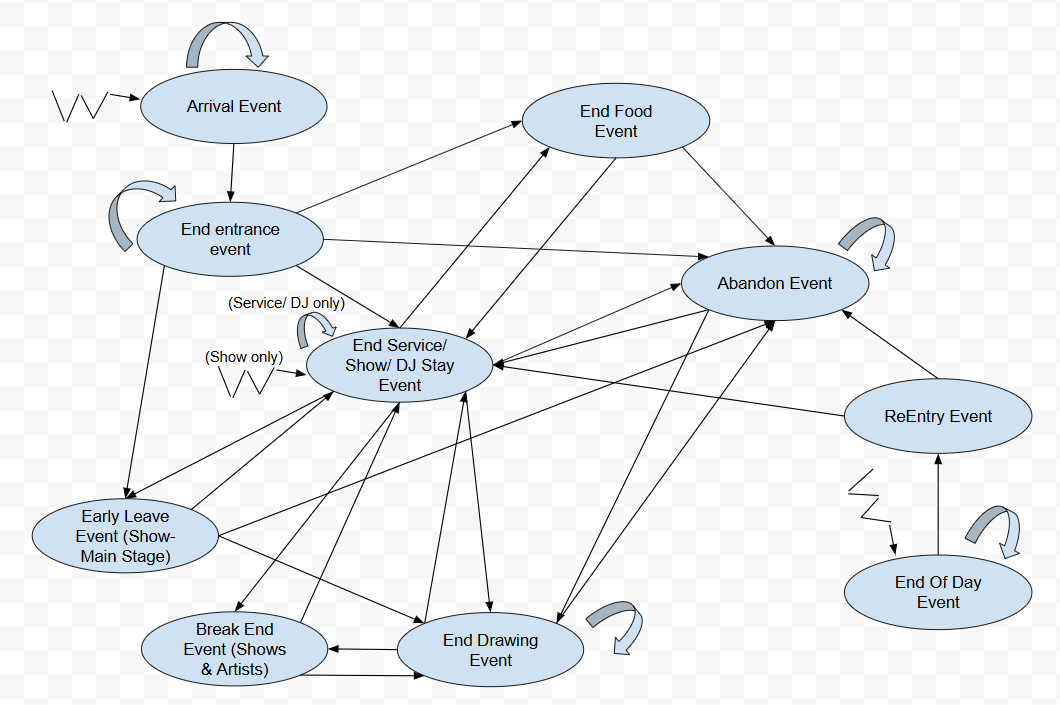

Arrival Event תרשים טיפול ב


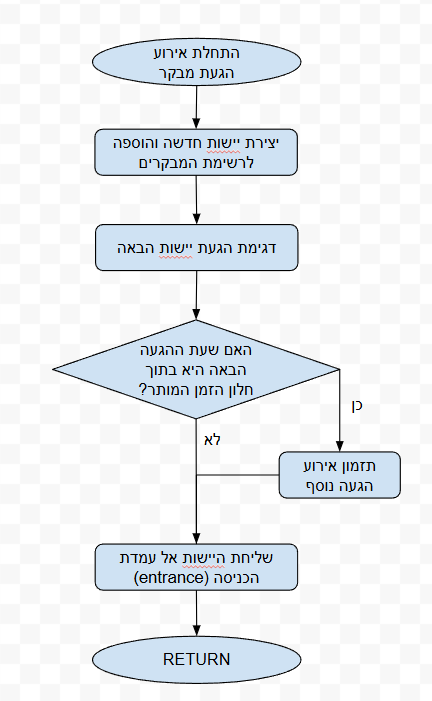

End drawing event תרשים טיפול ב

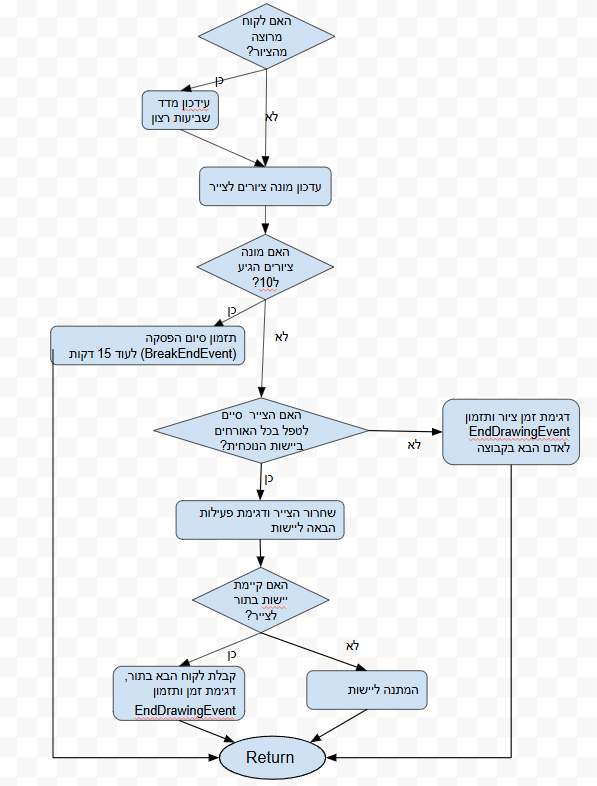

Abandon Event תרשים טיפול ב

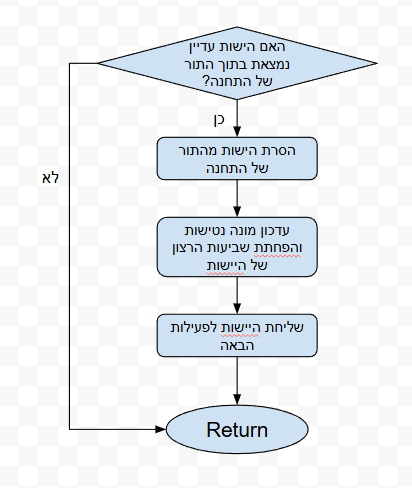

In [ ]:
# ── Event ────────────────────────────────────────────────────────────────────

class Event:
    """Abstract base class for all simulation events. Ordered by time (heapq)."""

    def __init__(self, time: float):
        self.time = time

    def __lt__(self, other):
        return self.time < other.time

    def handle(self, festival) -> None:
        raise NotImplementedError

    def __repr__(self):
        return f"{self.__class__.__name__}(time={self.time:.2f})"


# ── ArrivalEvent ──────────────────────────────────────────────────────────────

class ArrivalEvent(Event):
    """
    Handles the arrival of a NEW entity (not overnight re-entry).
    Creates entity, sends to entrance, schedules next arrival of same type.
    For overnight re-entry use ReEntryEvent.
    Festival needs: entities[], entrance, DAY_DURATION, can_schedule_arrival().
    """

    def __init__(self, time: float, entity_class):
        super().__init__(time)
        self.entity_class = entity_class  # must be a class, not an instance

    def handle(self, festival) -> None:
        day    = 1 if festival.clock < festival.DAY_DURATION else 2
        entity = self.entity_class(arrival_time=festival.clock, day=day)
        festival.entities.append(entity)

        next_arrival = festival.clock + entity.get_arrival_time()
        if festival.can_schedule_arrival(entity, next_arrival):
            festival.schedule(ArrivalEvent(next_arrival, self.entity_class))

        festival.entrance.add_to_queue(entity, festival)


# ── ReEntryEvent ──────────────────────────────────────────────────────────────

class ReEntryEvent(Event):
    """
    Handles the re-entry of an overnight entity at the start of Day 2.
    Skips the entrance: entity is already inside the festival grounds.
    Scheduled from entity.end_of_day when the entity stays overnight.
    """

    def __init__(self, time: float, entity):
        super().__init__(time)
        self.entity = entity

    def handle(self, festival) -> None:
        self.entity.get_next_activity(festival)


# ── EndServiceEvent ───────────────────────────────────────────────────────────

class EndServiceEvent(Event):
    """
    Handles completion of service at any station
    (Entrance, PhotoStation, ChargingStation, MerchTent).
    BodyArt uses EndDrawingEvent; food stalls use EndFoodEvent.
    Station._start_service must schedule: EndServiceEvent(end_time, entity, self)
    """

    def __init__(self, time: float, entity, station):
        super().__init__(time)
        self.entity  = entity
        self.station = station

    def handle(self, festival) -> None:
        if self.entity not in self.station.in_service:
            return
        self.station.end_service(self.entity, festival)


# ── EndShowEvent ──────────────────────────────────────────────────────────────

class EndShowEvent(Event):
    """
    Handles the end of a show at MainStage or SideStage.
    Stage.start_show must schedule: EndShowEvent(festival.clock + show_duration, self)
    Stage.end_show must schedule:   BreakEndEvent(festival.clock + break_duration, self)
    """

    def __init__(self, time: float, stage):
        super().__init__(time)
        self.stage = stage

    def handle(self, festival) -> None:
        self.stage.end_show(festival.clock, festival)


# ── BreakEndEvent ─────────────────────────────────────────────────────────────

class BreakEndEvent(Event):
    """
    Handles end of a break — two cases:
    1. Stage break (artist_id is None): calls stage.end_break(festival).
    2. BodyArt artist break (artist_id set): calls body_art.end_break(...).
    Stage.end_show must schedule:              BreakEndEvent(t + break_duration, stage)
    BodyArt.end_drawing must schedule:         BreakEndEvent(t + BREAK_DURATION,
                                                 body_art, artist_id, entity, people_done)
    """

    def __init__(self, time: float, source, artist_id: int = None,
                 entity=None, people_done: int = None):
        super().__init__(time)
        self.source      = source
        self.artist_id   = artist_id
        self.entity      = entity
        self.people_done = people_done

    def handle(self, festival) -> None:
        if self.artist_id is not None:
            self.source.end_break(self.artist_id, festival,
                                  self.entity, self.people_done)
        else:
            self.source.end_break(festival)


# ── EndDrawingEvent ───────────────────────────────────────────────────────────

class EndDrawingEvent(Event):
    """
    Handles completion of one person's drawing at BodyArt.
    BodyArt._start_next_drawing must schedule:
      EndDrawingEvent(end_time, entity, self, artist_id, art_type)
    """

    def __init__(self, time: float, entity, body_art, artist_id: int, art_type: str):
        super().__init__(time)
        self.entity    = entity
        self.body_art  = body_art
        self.artist_id = artist_id
        self.art_type  = art_type

    def handle(self, festival) -> None:
        if self.entity.id not in self.body_art.in_progress:
            return
        self.body_art.end_drawing(self.entity, festival,
                                  self.artist_id, self.art_type)


# ── EarlyLeaveEvent ───────────────────────────────────────────────────────────

class EarlyLeaveEvent(Event):
    """
    Handles potential early departure from MainStage (last 10 entities, prob 0.5).
    MainStage.start_show must schedule:
      EarlyLeaveEvent(festival.clock + EARLY_LEAVE_TIME, entity, self)
    """

    def __init__(self, time: float, entity, main_stage):
        super().__init__(time)
        self.entity     = entity
        self.main_stage = main_stage

    def handle(self, festival) -> None:
        if self.entity not in self.main_stage.current_occupants:
            return
        self.main_stage.handle_early_leave(self.entity, festival)


# ── EndStayDJ ──────────────────────────────────────────────────────────────

class EndStayDJ(Event):
    """
    Handles the end of an entity's stay at DJStage.
    DJStage._start_stay must schedule: EndStayDJ(exit_time, entity, self)
    """

    def __init__(self, time: float, entity, dj_stage):
        super().__init__(time)
        self.entity   = entity
        self.dj_stage = dj_stage

    def handle(self, festival) -> None:
        if self.entity not in self.dj_stage.current_occupants:
            return
        self.dj_stage.end_stay(self.entity, festival, festival.clock)


# ── EndFoodEvent ──────────────────────────────────────────────────────────────

class EndFoodEvent(Event):
    """
    Handles the end of food prep + eating.
    Restaurant.end_service must schedule:
      EndFoodEvent(festival.clock + prep_time + eating_time, entity, self)
    """

    def __init__(self, time: float, entity, restaurant):
        super().__init__(time)
        self.entity     = entity
        self.restaurant = restaurant

    def handle(self, festival) -> None:
        self.restaurant.end_eating(self.entity, festival)


# ── AbandonEvent ──────────────────────────────────────────────────────────────

class AbandonEvent(Event):
    """
    Handles entity abandonment from a station queue after patience expires.
    Scheduled in entity._enter_activity:
      AbandonEvent(festival.clock + entity.patience, entity, activity)
    Patience (minutes): FriendsGroup=15, Couple=20, Single=20.
    """

    def __init__(self, time: float, entity, station):
        super().__init__(time)
        self.entity  = entity
        self.station = station

    def handle(self, festival) -> None:
        if self.entity not in [v[0] for v in self.station.activity_queue.queue]:
            return
        self.station.activity_queue.handle_abandon(self.entity, festival.clock)
        self.entity.get_next_activity(festival)


# ── EndOfDayEvent ─────────────────────────────────────────────────────────────

class EndOfDayEvent(Event):
    """
    Handles end of day at 20:00 for all active entities.
    Scheduled at simulation start for t=DAY_DURATION (end of Day 1),
    then re-schedules itself for t=2*DAY_DURATION (end of Day 2).
    Festival needs: entities[], current_day, DAY_DURATION.
    """

    def __init__(self, time: float):
        super().__init__(time)

    def handle(self, festival) -> None:
      festival.simulator.print_day_report(festival.current_day, is_start=False)

      # --- Remove entities still stuck in the entrance queue (never entered) ---
      entrance_queue = festival.entrance.activity_queue
      not_entered = []
      for entity, arrival_time in list(entrance_queue.queue):
        not_entered.append(entity)
        festival.entities.remove(entity)   # remove from entities — they never entered

      entrance_queue.queue.clear()

      if not_entered:
        print(f"  Entities that did not enter the festival (day closed): {len(not_entered)}")

      # --- Clear all other queues at closing ---
      other_spots = [s for s in list(festival.activities.values()) + list(festival.restaurants.values())
                   if s is not festival.entrance]
      for spot in other_spots:
        q = getattr(spot, "activity_queue", None)
        if q is None:
            continue
        for entity, arrival_time in list(q.queue):
            q.record_waiting_time(arrival_time, festival.clock)
        q.queue.clear()

      # --- End of day for all remaining entities ---
      for entity in festival.entities:
        if not entity.has_finished_all:
            entity.end_of_day(festival)

      if festival.current_day == 1:
        festival.current_day = 2
        festival.simulator.print_day_report(2, is_start=True)
        festival.schedule(EndOfDayEvent(festival.clock + festival.DAY_DURATION))


# Festival

In [ ]:
# @title
class Festival:
    """
    Contains all festival components, state, and scheduling logic.
    Represents the current state of the festival at any point in time.
    """

    DAY_DURATION = 660.0  # 11 hours * 60 min (09:00 - 20:00)

    def __init__(self):
        # --- time ---
        self.clock        = 0.0
        self.current_day  = 1

        # --- financials ---
        self.total_revenue = 0.0

        # --- debug mode ---
        self.debug_mode = False # Set to True to enable debug prints

        # --- entities ---
        self.entities = []

        # --- event queue ---
        self.event_queue = []
        heapq.heapify(self.event_queue)

        # --- simulator reference (for reporting) ---
        self.simulator = None

        # --- initialize components ---
        self._init_stations()
        self._init_stages()
        self._init_food()

    # ── Initialization ────────────────────────────────────────────────────────

    def _init_stations(self) -> None:
        """Initialize all stations."""
        self.entrance         = Entrance()
        self.photo_station    = PhotoStation()
        self.charging_station = ChargingStation()
        self.merch_tent       = MerchTent()
        self.body_art         = BodyArt()

        # dict for easy lookup by entities
        self.activities = {
            "entrance":         self.entrance,
            "photo_station":    self.photo_station,
            "charging_station": self.charging_station,
            "merch_tent":       self.merch_tent,
            "body_art":         self.body_art,
        }

    def _init_stages(self) -> None:
        """Initialize all stages."""
        self.main_stage = MainStage()
        self.side_stage = SideStage()
        self.dj_stage   = DJStage()

        self.activities.update({
            "main_stage": self.main_stage,
            "side_stage": self.side_stage,
            "dj_stage":   self.dj_stage,
        })

    def _init_food(self) -> None:
        """Initialize food court restaurants."""
        self.pizza  = Pizza()
        self.burger = Burger()
        self.asian  = Asian()

        self.restaurants = {
            "pizza":  self.pizza,
            "burger": self.burger,
            "asian":  self.asian,
        }

    # ── Scheduling ────────────────────────────────────────────────────────────

    def schedule(self, event) -> None:
        """Add event to priority queue."""
        heapq.heappush(self.event_queue, event)

    def can_schedule_arrival(self, entity, next_arrival: float) -> bool:
        """
        Check if next arrival is within entity's allowed arrival window.
        Windows are in minutes from 09:00 on each day:
          FriendsGroup: day 1 only, 09:00-13:00 (0-240 min)
          Couple:       day 1+2,   10:00-16:00 (60-420 min per day)
          Single:       day 1+2,   09:00-16:00 (0-420 min per day)
        """
        day_offset = (entity.day - 1) * self.DAY_DURATION

        if entity.visitor_type == "FriendsGroup":
            return entity.day == 1 and next_arrival <= day_offset + 240

        if entity.visitor_type == "Couple":
            return (day_offset + 60 <= next_arrival <= day_offset + 420)

        if entity.visitor_type == "Single":
            return (day_offset <= next_arrival <= day_offset + 420)

        return False

    def send_to_food(self, entity) -> None:
        """
        Route entity to a food court restaurant by probability.
        Burger: 3/8, Pizza: 1/4, Asian: 3/8.
        Called from EndActivityEvent when clock is between 13:00-15:00.
        """
        idx = SamplingAlgorithms.multinomial([3/8, 1/4, 3/8])
        restaurant = list(self.restaurants.values())[idx]
        restaurant.add_to_queue(entity, self)

    # ── Statistics ────────────────────────────────────────────────────────────

    def get_stats(self) -> dict:
        """Return summary statistics for the simulation run."""
        return {
            "total_revenue":   self.total_revenue,
            "total_entities":  len(self.entities),
            "avg_satisfaction": (sum(e.satisfaction for e in self.entities) /
                                len(self.entities) if self.entities else 0),
        }

    def __repr__(self):
        return (f"Festival(day={self.current_day}, "
                f"clock={self.clock:.1f}, "
                f"revenue={self.total_revenue:.0f})")

# Simulator

In [ ]:
# ============================================================================
#  COMPREHENSIVE SIMULATION SUMMARY & INSIGHTS
#  Run this cell AFTER the simulation has finished (after sim.run()).
#  It reads the final state of `sim.festival` and prints all key metrics
#  plus automatically-derived insights (bottlenecks, capacity, satisfaction).
# ============================================================================

def print_full_summary(sim):
    f   = sim.festival
    ent = f.entities
    bar = "=" * 64
    sub = "-" * 64

    # ---- helpers -----------------------------------------------------------
    def by_type(predicate=lambda e: True):
        d = {"Single": [], "Couple": [], "FriendsGroup": []}
        for e in ent:
            if predicate(e):
                d[e.visitor_type].append(e)
        return d

    groups = by_type()

    # ---- 1. FINANCIAL ------------------------------------------------------
    print("\n" + bar)
    print("  COMPREHENSIVE FESTIVAL SUMMARY")
    print(bar)

    print("\n[1] FINANCIAL PERFORMANCE")
    print(sub)
    print(f"  Total revenue                : {f.total_revenue:>14,.0f} NIS")
    total_people = sum(e.num_people() for e in ent)
    if total_people:
        print(f"  Revenue per person           : {f.total_revenue/total_people:>14,.0f} NIS")
    if ent:
        print(f"  Revenue per entity           : {f.total_revenue/len(ent):>14,.0f} NIS")

    # ---- 2. CROWD ----------------------------------------------------------
    print("\n[2] CROWD STATISTICS")
    print(sub)
    print(f"  {'Type':<16}{'Entities':>10}{'People':>10}")
    for vt, lst in groups.items():
        ppl = sum(e.num_people() for e in lst)
        print(f"  {vt:<16}{len(lst):>10}{ppl:>10}")
    print(f"  {'TOTAL':<16}{len(ent):>10}{total_people:>10}")

    # ---- 3. SATISFACTION ---------------------------------------------------
    print("\n[3] VISITOR SATISFACTION (0-10)")
    print(sub)
    def avg(lst): return sum(e.satisfaction for e in lst)/len(lst) if lst else 0.0
    print(f"  {'Type':<16}{'Avg':>8}{'Min':>8}{'Max':>8}")
    for vt, lst in groups.items():
        if lst:
            sats = [e.satisfaction for e in lst]
            print(f"  {vt:<16}{sum(sats)/len(sats):>8.2f}{min(sats):>8.1f}{max(sats):>8.1f}")
    if ent:
        all_s = [e.satisfaction for e in ent]
        print(f"  {'OVERALL':<16}{sum(all_s)/len(all_s):>8.2f}{min(all_s):>8.1f}{max(all_s):>8.1f}")
        # distribution
        low  = sum(1 for s in all_s if s < 4)
        mid  = sum(1 for s in all_s if 4 <= s < 7)
        high = sum(1 for s in all_s if s >= 7)
        n = len(all_s)
        print(f"\n  Distribution:  low (<4): {low} ({100*low/n:.0f}%)   "
              f"mid (4-7): {mid} ({100*mid/n:.0f}%)   "
              f"high (>=7): {high} ({100*high/n:.0f}%)")

    # ---- 4. QUEUES ---------------------------------------------------------
    print("\n[4] QUEUE & SERVICE STATISTICS")
    print(sub)
    print(f"  {'Activity':<18}{'AvgWait':>9}{'AvgQueue':>10}{'Served':>9}{'Abandoned':>11}")

    all_queue_rows = []
    for name, act in f.activities.items():
        q = getattr(act, "activity_queue", None)
        if q is None:
            continue
        avg_len, avg_wait = q.calc_daily_statistics(sim.SIM_DURATION)
        served    = getattr(act, "total_served", 0)
        abandoned = getattr(q, "abandoned_count", 0)
        all_queue_rows.append((name, avg_wait, avg_len, served, abandoned))

    for name, rest in f.restaurants.items():
        q = getattr(rest, "activity_queue", None)
        if q is None:
            continue
        avg_len, avg_wait = q.calc_daily_statistics(sim.SIM_DURATION)
        served    = getattr(rest, "total_served", 0)
        abandoned = getattr(q, "abandoned_count", 0)
        all_queue_rows.append((name, avg_wait, avg_len, served, abandoned))

    # Define the custom order for activities and restaurants
    custom_order = [
        "entrance", "merch_tent", "photo_station", "charging_station", "body_art",
        "main_stage", "side_stage", "dj_stage",
        "asian", "burger", "pizza"
    ]
    order_map = {name: i for i, name in enumerate(custom_order)}

    # Sort all_queue_rows according to the custom order
    all_queue_rows.sort(key=lambda x: order_map.get(x[0], len(custom_order))) # Use a large index for unexpected items

    # Print the sorted rows
    for row in all_queue_rows:
        print(f"  {row[0]:<18}{row[1]:>9.2f}{row[2]:>10.2f}{row[3]:>9}{row[4]:>11}")

    # Use the combined and sorted list for insights
    queue_rows = all_queue_rows

    # ---- 5. OVERNIGHT & ABANDONMENT ---------------------------------------
    print("\n[5] BEHAVIOR")
    print(sub)
    total_abandoned = sum(getattr(getattr(a, "activity_queue", None), "abandoned_count", 0)
                          for a in list(f.activities.values()) + list(f.restaurants.values())
                          if getattr(a, "activity_queue", None))
    print(f"  Total queue abandonments     : {total_abandoned}")
    day2 = sum(1 for e in ent if getattr(e, "day", 1) == 2)
    print(f"  Entities active on day 2     : {day2}  (overnight stays + day-2 arrivals)")

    # ---- 6. AUTOMATIC INSIGHTS --------------------------------------------
    print("\n[6] KEY INSIGHTS (auto-derived)")
    print(sub)
    if queue_rows:
        worst = max(queue_rows, key=lambda r: r[1])
        print(f"  * Biggest bottleneck: '{worst[0]}' "
              f"(avg wait {worst[1]:.0f} min, avg queue {worst[2]:.0f}).")
        idle = [r[0] for r in queue_rows if r[2] < 0.5 and r[3] > 0]
        if idle:
            print(f"  * Over-capacity (no queue forms): {', '.join(idle)} "
                  f"-- demand never exceeds capacity.")
    if ent:
        overall = sum(e.satisfaction for e in ent)/len(ent)
        if overall < 5.5:
            print(f"  * Overall satisfaction ({overall:.2f}) is low -- likely dragged "
                  f"down by the bottleneck above and end-of-day evictions.")
    if total_abandoned > 0.2 * len(ent):
        print(f"  * High abandonment ({total_abandoned}) signals station queues "
              f"exceed visitor patience.")

    print("\n" + bar)
    print("  END OF SUMMARY")
    print(bar)

In [ ]:
class Simulator:
    """
    Simulation engine. Manages the event loop and runs the festival simulation.
    Separate from Festival (state) to keep concerns clean.
    """

    # festival runs for 2 days, each 11 hours (09:00-20:00)
    SIM_DURATION = 2 * 660.0

    # Arrival windows for visitors
    SINGLE_OPEN = 0.0
    COUPLE_OPEN = 60.0

    def __init__(self):
        self.festival = Festival()
        self.festival.simulator = self # Assign the simulator instance to the festival

    # ── Run ───────────────────────────────────────────────────────────────────

    def run(self) -> None:
        """
        Main simulation loop.
        Initializes arrivals and end-of-day events, then processes events.
        """
        print("\n" + "=" * 50)
        print("  <<< Festival Simulation Starting >>>")
        print("=" * 50)

        self._initialize_arrivals()
        self._initialize_end_of_days()
        self._initialize_stages()

        while self.festival.event_queue:
          event = heapq.heappop(self.festival.event_queue)
          if event.time > self.SIM_DURATION:   # ← הוסיפי שורה זו
            break
          self.festival.clock = event.time
          event.handle(self.festival)


        print("\n" + "=" * 50)
        print("  <<< Festival Simulation Ended >>>")
        print("=" * 50)

    # ── Initialization ────────────────────────────────────────────────────────

    def _initialize_arrivals(self) -> None:
        """
        Schedule first arrival for each entity type.
        Creates a temporary entity to sample first inter-arrival time.
        """
        entity_types = [Single, Couple, FriendsGroup]
        window_open = {"Single": self.SINGLE_OPEN, "Couple": self.COUPLE_OPEN, "FriendsGroup": 0}

        for entity_class in entity_types:
            # Day 1 arrivals (first arrival must fall inside the type's window)
            temp1 = entity_class(arrival_time=0.0, day=1)
            open1 = window_open[temp1.visitor_type]
            first_arrival_day1 = open1 + temp1.get_arrival_time()
            if self.festival.can_schedule_arrival(temp1, first_arrival_day1):
                self.festival.schedule(ArrivalEvent(first_arrival_day1, entity_class))

            # Day 2 arrivals
            temp2 = entity_class(arrival_time=self.festival.DAY_DURATION, day=2)
            open2 = self.festival.DAY_DURATION + window_open[temp2.visitor_type]
            first_arrival_day2 = open2 + temp2.get_arrival_time()
            if self.festival.can_schedule_arrival(temp2, first_arrival_day2):
                self.festival.schedule(ArrivalEvent(first_arrival_day2, entity_class))

    def _initialize_end_of_days(self) -> None:
        """
        Schedule end of day events for both days.
        """
        self.festival.schedule(EndOfDayEvent(660.0))   # day 1: 20:00
        # Removed the redundant scheduling for day 2. EndOfDayEvent.handle() re-schedules itself.
        # self.festival.schedule(EndOfDayEvent(1320.0))  # day 2: 20:00

    def _initialize_stages(self) -> None:
        """
        Explicitly start the first show for MainStage and SideStage.
        DJStage is continuous flow and handles its own entry/exit.
        """
        # Immediately start the first show for MainStage and SideStage.
        # This will trigger EndShowEvent and subsequent breaks/shows.
        self.festival.main_stage.start_show(self.festival)
        self.festival.side_stage.start_show(self.festival)
        # DJStage operates differently and doesn't need an explicit 'start_show' call at t=0.
        # Entities are processed as they arrive or are pulled from its queue.

    # ── Reporting ─────────────────────────────────────────────────────────────

    def get_real_time(self) -> str:
        """Convert simulation clock to HH:MM format (day aware)."""
        clock    = self.festival.clock % 660.0
        day      = self.festival.current_day
        total    = 9 * 60 + clock
        hours    = int(total // 60)
        minutes  = int(total % 60)
        return f"Day {day} - {hours:02d}:{minutes:02d}"

    def print_report(self) -> None:
        """
        Print final simulation report.
        """
        f = self.festival
        print("\n" + "=" * 50)
        print(f"     FESTIVAL REPORT") # Changed title to remove time
        print("=" * 50)

        # financial
        print(f"\n[FINANCIAL PERFORMANCE]")
        print(f"Total Revenue: {f.total_revenue:,.2f} NIS")

        # crowd
        print(f"\n[CROWD STATISTICS]")
        print(f"Total Entities:  {len(f.entities)}")
        total_people = sum(e.num_people() for e in f.entities)
        print(f"Total People:    {total_people}")

        # satisfaction
        print(f"\n[VISITOR SATISFACTION]")
        if f.entities:
            avg_sat = sum(e.satisfaction for e in f.entities) / len(f.entities)
            print(f"Avg Satisfaction: {avg_sat:.2f} / 10")

        # queues
        print(f"\n[QUEUE STATISTICS]")
        for name, activity in f.activities.items():
            # Ensure activity_queue attribute exists for all activities
            if hasattr(activity, 'activity_queue'):
                avg_len, avg_wait = activity.activity_queue.calc_daily_statistics(
                    self.SIM_DURATION)
                print(f"{name:<20} | Avg Wait: {avg_wait:>6.2f} min "
                      f"| Avg Queue: {avg_len:>5.2f}")
            else:
                print(f"{name:<20} | No queue statistics available.")

        print("\n" + "=" * 50)
        print("           END OF SIMULATION")
        print("=" * 50)

    def print_day_report(self, day_num: int, is_start: bool) -> None:
        """
        Prints a report for the start or end of a day.
        """
        f = self.festival
        print("\n" + "=" * 50)
        if is_start:
            print(f"     <<< Day {day_num} Started >>>")
        else:
            print(f"     <<< Day {day_num} Ended >>>")
            print(f"Current Revenue: {f.total_revenue:,.2f} NIS")
            if f.entities:
                avg_sat = sum(e.satisfaction for e in f.entities) / len(f.entities)
                print(f"Average Satisfaction: {avg_sat:.2f} / 10")
        print("=" * 50)

# ── Entry point ───────────────────────────────────────────────────────────────

def main():
    sim = Simulator()
    sim.run()
    print_full_summary(sim)

if __name__ == "__main__":
    main()


  <<< Festival Simulation Starting >>>

     <<< Day 1 Ended >>>
Current Revenue: 1,084,350.00 NIS
Average Satisfaction: 5.18 / 10
  Entities that did not enter the festival (day closed): 264

     <<< Day 2 Started >>>

     <<< Day 2 Ended >>>
Current Revenue: 1,873,680.00 NIS
Average Satisfaction: 5.60 / 10
  Entities that did not enter the festival (day closed): 85

  <<< Festival Simulation Ended >>>

  COMPREHENSIVE FESTIVAL SUMMARY

[1] FINANCIAL PERFORMANCE
----------------------------------------------------------------
  Total revenue                :      1,873,680 NIS
  Revenue per person           :            706 NIS
  Revenue per entity           :          1,218 NIS

[2] CROWD STATISTICS
----------------------------------------------------------------
  Type              Entities    People
  Single                 832       832
  Couple                 534      1068
  FriendsGroup           172       753
  TOTAL                 1538      2653

[3] VISITOR SATISFACTION 

#Metrics


<div dir="rtl" style="text-align: right; font-family: Arial; line-height: 1.6;">

<h3><b>מדדים שנבחרו לבדיקה</b></h3>

<p>
כחלק מהסימולציה נבחרו שני מדדים מרכזיים לצורך ניתוח ביצועי הפסטיבל, איכות חוויית המבקרים וההשפעה הכלכלית של החלופות השונות.
</p>

<p><b>ממוצע שביעות רצון המבקרים</b><br>
מדד זה מייצג את רמת שביעות הרצון הממוצעת של המבקרים בסיום הביקור בפסטיבל. המדד מחושב על בסיס דירוגי שביעות הרצון של כלל הישויות שהשתתפו בסימולציה, לאחר עדכונים שנבעו מצפייה בהופעות, שימוש בתחנות, חוויית אוכל ונטישות תור.
</p>

<p>
מדד זה מאפשר להעריך את איכות חוויית המבקרים ואת השפעת החלופות השונות על רמת שביעות הרצון הכוללת בפסטיבל.
</p>

<p><b>סך כל הכנסות הפסטיבל</b><br>
מדד זה מייצג את סך ההכנסות של הפסטיבל לאורך ימי הפעילות, הכוללות הכנסות מכרטיסי כניסה, לינה, רכישות במרצ'נדייז, דוכני אוכל ותמונות מודפסות. המדד מחושב כסכום כלל ההכנסות שנצברו במהלך הסימולציה.
</p>

<p>
מדד זה משמש להערכת הביצועים הכלכליים של הפסטיבל ולהשוואת התרומה הכלכלית של כל אחת מהחלופות הנבחנות.
</p>

</div>


# Alternative's

<div dir="rtl">

# השוואת חלופות לשיפור המערכת

לאחר בחינת מספר אפשרויות לשיפור ביצועי המערכת, נבחרו שתי קומבינציות חלופיות להשוואה מול מצב הבסיס (Base). שתי החלופות נבנו כך שיעמדו במסגרת התקציב שהוגדרה, עד 1,000,000 ₪, כאשר העלות הכוללת של כל חלופה עומדת על 950,000 ₪.

בחירת החלופות לא בוצעה באופן אקראי, אלא התבססה על מספר הרצות מקדימות של הסימולציה שבוצעו לפני שלב ההשוואה הסופי. מטרת ההרצות הייתה לבחון אילו פרמטרים משפיעים באופן המשמעותי ביותר על ביצועי המערכת ולאתר מוקדי עומס, צווארי בקבוק והזדמנויות לשיפור.

על סמך תוצאות ההרצות והניתוח שבוצע לאחריהן, גובשו מספר שילובי השקעה אפשריים במסגרת מגבלת התקציב, ומתוכם נבחרו שתי החלופות שלהערכתנו צפויות להביא לשיפור המשמעותי ביותר במדדי הביצוע שנבחרו.

---

## מצב בסיס (Base)

המערכת במצבה הנוכחי, ללא שינוי בפרמטרים.

---

## חלופה 1 – שיפור חוויית הכניסה והאטרקציות  
**עלות כוללת: 950,000 ₪**

| רכיב | עלות | שינוי שבוצע |
|---|---:|---|
| הטבת מבקרים | 200,000 ₪ | שביעות רצון התחלתית: 5.0 → 6.5 |
| סריקת כרטיסים אוטומטית | 600,000 ₪ | זמן השירות בכניסה כולל בידוק ביטחוני בלבד |
| הרחבת אזור האטרקציות | 150,000 ₪ | PhotoStation: 3 → 4, BodyArt: 2 → 3 |

---

## חלופה 2 – שיפור שירותי המזון והתוכן באירוע  
**עלות כוללת: 950,000 ₪**

| רכיב | עלות | שינוי שבוצע |
|---|---:|---|
| שדרוג צוות המטבח | 500,000 ₪ | הסתברות לארוחה גרועה: 0.4 → 0.1, הסתברות לאכילת צהריים: 0.7 → 0.85 |
| השקעה בלהקות פופולריות | 300,000 ₪ | הסתברות לרכישת חולצת להקה: 0.3 → 0.8, משקל ז'אנר mainstream: 3 → 4 |
| הרחבת אזור האטרקציות | 150,000 ₪ | PhotoStation: 3 → 4, BodyArt: 2 → 3 |

---

## מדדי השוואה

1. הכנסה כוללת (Total Revenue)  
2. שביעות רצון ממוצעת של המבקרים (Average Visitor Satisfaction)

---

## מתודולוגיה סטטיסטית

ההשוואה בין התרחישים בוצעה באמצעות מתודולוגיה סטטיסטית שנועדה להבטיח תוצאות מהימנות ובעלות מובהקות מספקת.

- רמת ביטחון: **90%**
- דיוק יחסי: **10%**
- שימוש בתיקון בונפרוני לצורך התמודדות עם השוואות מרובות
- ביצוע שלב פיילוט הכולל \(N_0\) הרצות לצורך אומדן השונות
- חישוב מספר ההרצות הנדרש \(N\)

בנוסף, לצמצום השונות בין התרחישים ולהגדלת איכות ההשוואה בין החלופות לבין מצב הבסיס, נעשה שימוש בשיטת **Common Random Numbers (CRN)**.

בכל הרצה \(i\) נעשה שימוש באותו seed אקראי עבור כלל התרחישים (`random.seed(i)`)  כלומר, בהרצה הראשונה ה־seed היה 0, בהרצה השנייה 1, וכן הלאה. בצורה זו ההבדלים שהתקבלו נבעו בעיקר מהשינויים שבוצעו במערכת ולא מהשפעות אקראיות של הסימולציה.

</div>

In [ ]:
# ============================================================================
#  חלופות (Alternatives) — Scenario Configuration
# ============================================================================

def set_base_configuration():
    """
    Base — מצב קיים: כל הפרמטרים מוחזרים לערכי ברירת המחדל המקוריים.
    """
    Entity.INITIAL_SATISFACTION = 5.0
    Entity.LUNCH_PROBABILITY    = 0.7

    Entrance.SKIP_TICKET_SCAN = False

    PhotoStation.NUM_SERVERS = 3
    BodyArt.NUM_ARTISTS      = 2

    Restaurant.BAD_MEAL_PROBABILITY = 0.4

    MerchTent.ITEMS = {
        "festival_shirt":  (0.8, 100),
        "festival_hat":    (0.4,  50),
        "flag":            (0.9,  40),
        "band_shirt":      (0.3, 200),
    }

    Stage.GENRE_WEIGHTS = {"mainstream": 3, "indie": 2, "electronic": 1}


def set_alt1_configuration():
    """
    חלופה 1 (950,000 ש"ח):
      - הטבת מבקרים (200,000 ש"ח): שביעות רצון התחלתית 5.0 -> 6.5
      - סריקת כרטיסים אוטומטית (600,000 ש"ח): זמן השירות בכניסה = בדיקה ביטחונית בלבד
      - תוספת אומן ציור גוף + עמדת צילום (150,000 ש"ח): PhotoStation 3->4, BodyArt 2->3
    """
    set_base_configuration()

    Entity.INITIAL_SATISFACTION = 6.5
    Entrance.SKIP_TICKET_SCAN   = True
    PhotoStation.NUM_SERVERS    = 4
    BodyArt.NUM_ARTISTS         = 3


def set_alt2_configuration():
    """
    חלופה 2 (950,000 ש"ח):
      - צוות מטבח משודרג (500,000 ש"ח): הסתברות לארוחה גרועה 0.4 -> 0.1,
        הסתברות לאכילת צהריים 0.7 -> 0.85
      - השקעה בלהקות פופולריות (300,000 ש"ח): הסתברות לרכישת band_shirt 0.3 -> 0.8,
        משקל ז'אנר mainstream 3 -> 4
      - תוספת אומן ציור גוף + עמדת צילום (150,000 ש"ח): PhotoStation 3->4, BodyArt 2->3
    """
    set_base_configuration()

    Restaurant.BAD_MEAL_PROBABILITY = 0.1
    Entity.LUNCH_PROBABILITY        = 0.85

    MerchTent.ITEMS = dict(MerchTent.ITEMS)
    MerchTent.ITEMS["band_shirt"] = (0.8, 200)

    Stage.GENRE_WEIGHTS = dict(Stage.GENRE_WEIGHTS)
    Stage.GENRE_WEIGHTS["mainstream"] = 4

    PhotoStation.NUM_SERVERS = 4
    BodyArt.NUM_ARTISTS      = 3


SCENARIOS = {
    "Base": set_base_configuration,
    "Alt1": set_alt1_configuration,
    "Alt2": set_alt2_configuration,
}


In [ ]:
import io
import contextlib
import pandas as pd
from scipy import stats

# תצוגה נקייה של מספרים בטבלאות (ללא e+06 / e+00)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


def run_single_replication(seed: int) -> dict:
    """
    מריצה הרצה בודדת של הסימולציה עם seed נתון, ומחזירה את המדדים שנבחרו להשוואה.
    """
    random.seed(seed)
    Entity._id_counter = 0

    sim = Simulator()
    with contextlib.redirect_stdout(io.StringIO()):
        sim.run()

    f = sim.festival
    avg_satisfaction = sum(e.satisfaction for e in f.entities) / len(f.entities)

    return {
        "Total Revenue":    f.total_revenue,
        "Avg Satisfaction": avg_satisfaction,
    }


def run_replications(config_func, n: int) -> pd.DataFrame:
    """
    מריצה n הרצות (seed = 0..n-1) תחת קונפיגורציה נתונה, ומחזירה DataFrame
    שבו כל שורה היא הרצה אחת והעמודות הן המדדים שנמדדים.
    """
    config_func()
    rows = [run_single_replication(seed) for seed in range(n)]
    return pd.DataFrame(rows, index=[f"Run {i + 1}" for i in range(n)])


<div dir="rtl" style="text-align: right; font-family: Arial; line-height: 1.6;">

<p>
בשלב הראשון בוצעה הרצת פיילוט עבור כל אחד מהתרחישים שנבדקו: מצב הבסיס ושתי החלופות. בכל תרחיש הורצו 10 הרצות ראשוניות, כאשר בכל הרצה נאספו שני מדדי הביצוע שנבחרו להשוואה: סך ההכנסות ושביעות הרצון הממוצעת של המבקרים. מטרת הפיילוט הייתה להעריך את רמת השונות בתוצאות ולקבוע כמה הרצות נדרשות בסימולציה הסופית כדי לקבל תוצאות מדויקות מספיק.
</p>

<p>
על בסיס תוצאות הפיילוט חושבו עבור כל מדד בכל תרחיש הממוצע, סטיית התקן, חצי רוחב רווח הסמך והדיוק היחסי. החישוב בוצע ברמת ביטחון כוללת של 90% וברמת דיוק יחסית של 10%. מכיוון שבוצעו מספר השוואות בין תרחישים ובין מדדים, נעשה שימוש בתיקון Bonferroni לרמת המובהקות, כדי לשמור על רמת הביטחון הכוללת של הניתוח.
</p>

<p>
לאחר מכן חושב מספר ההרצות הנדרש עבור כל מדד ותרחיש, ומספר ההרצות הסופי נבחר כמקסימום מבין כל הערכים שהתקבלו. בצורה זו מובטח שכל התרחישים נבדקים באותו מספר הרצות וברמת דיוק סטטיסטית אחידה.
</p>

</div>


In [ ]:
# ============================================================================
#  שלב 1: הרצת פיילוט וחישוב מספר ההרצות הנדרש (N)
# ============================================================================

CONFIDENCE_LEVEL   = 0.90
RELATIVE_PRECISION = 0.10
N0                 = 10                   # מספר הרצות הפיילוט
METRICS            = ["Total Revenue", "Avg Satisfaction"]
ALTERNATIVES       = ["Alt1", "Alt2"]      # חלופות שמושוות מול Base
COMPARISON_PAIRS   = [("Alt1", "Base"), ("Alt2", "Base"), ("Alt1", "Alt2")]  # כל ההשוואות הזוגיות

NUM_COMPARISONS  = len(COMPARISON_PAIRS) * len(METRICS)
ALPHA            = 1 - CONFIDENCE_LEVEL
ALPHA_BONFERRONI = ALPHA / NUM_COMPARISONS

# קריטריון הדיוק היחסי (Law & Kelton): half-width / |mean| <= gamma / (1 + gamma)
TARGET_PRECISION = RELATIVE_PRECISION / (1 + RELATIVE_PRECISION)

print(f"רמת בטחון כוללת: {CONFIDENCE_LEVEL},  דיוק יחסי: {RELATIVE_PRECISION}  (סף יעד: {TARGET_PRECISION:.2%})")
print(f"מספר השוואות: {NUM_COMPARISONS}  ->  alpha מתוקן (בונפרוני) = {ALPHA_BONFERRONI:.4f}")
print(f"\nמריץ פיילוט של {N0} הרצות לכל תרחיש...")

pilot_results = {name: run_replications(cfg, N0) for name, cfg in SCENARIOS.items()}

t_pilot = stats.t.ppf(1 - ALPHA_BONFERRONI / 2, df=N0 - 1)

print(f"\n{'Scenario':>8} | {'Metric':<18} | {'Mean':>14} | {'Precision':>9} | OK? | N נדרש")
required_N = N0
for name, df_pilot in pilot_results.items():
    for metric in METRICS:
        mean = df_pilot[metric].mean()
        std  = df_pilot[metric].std(ddof=1)
        half_width = t_pilot * std / math.sqrt(N0)
        precision  = half_width / abs(mean)
        n_needed   = math.ceil((t_pilot * std / (TARGET_PRECISION * abs(mean))) ** 2)
        required_N = max(required_N, n_needed)
        status = "V" if precision <= TARGET_PRECISION else "X"
        print(f"{name:>8} | {metric:<18} | {mean:>14,.3f} | {precision:>8.2%} | {status:^3} | {n_needed}")

N = max(N0, required_N)
print(f"\nמספר ההרצות הסופי לכל תרחיש: N = {N}")


רמת בטחון כוללת: 0.9,  דיוק יחסי: 0.1  (סף יעד: 9.09%)
מספר השוואות: 6  ->  alpha מתוקן (בונפרוני) = 0.0167

מריץ פיילוט של 10 הרצות לכל תרחיש...

Scenario | Metric             |           Mean | Precision | OK? | N נדרש
    Base | Total Revenue      |  1,898,278.000 |    2.40% |  V  | 1
    Base | Avg Satisfaction   |          5.609 |    1.09% |  V  | 1
    Alt1 | Total Revenue      |  2,220,661.000 |    2.10% |  V  | 1
    Alt1 | Avg Satisfaction   |          6.874 |    0.58% |  V  | 1
    Alt2 | Total Revenue      |  2,076,947.500 |    2.53% |  V  | 1
    Alt2 | Avg Satisfaction   |          5.925 |    0.80% |  V  | 1

מספר ההרצות הסופי לכל תרחיש: N = 10


<p dir="rtl">
בהתאם לתוצאות הפיילוט, בכל התרחישים והמדדים שנבדקו התקבל דיוק יחסי נמוך מסף היעד שהוגדר, העומד על כ־9.09%.
ערכי ה־Precision שהתקבלו נעו בין 0.58% ל־2.53%, ולכן כולם עמדו בדרישת הדיוק כבר לאחר 10 הרצות הפיילוט.
משמעות הדבר היא שהשונות בין ההרצות הייתה נמוכה יחסית לערכי הממוצע של המדדים, ולכן לפי נוסחת חישוב גודל המדגם לא נדרשה הגדלה של מספר ההרצות.
בהתאם לכך, מספר ההרצות הסופי לכל תרחיש נותר 10.
</p>

In [ ]:
# ============================================================================
#  שלב 2: הרצות סופיות וטבלאות סיכום לכל תרחיש
# ============================================================================

final_results = {}
for name, cfg in SCENARIOS.items():
    final_results[name] = pilot_results[name] if N == N0 else run_replications(cfg, N)

for name, df_runs in final_results.items():
    df_summary = df_runs.copy()
    df_summary.loc["Average"] = df_runs.mean()
    df_summary.loc["Std Dev"] = df_runs.std(ddof=1)
    print(f"\n--- {name} ---")
    display(df_summary)



--- Base ---


,Total Revenue,Avg Satisfaction
Run 1,"1,942,555.00",5.54
Run 2,"1,882,195.00",5.64
Run 3,"1,876,040.00",5.70
Run 4,"1,882,155.00",5.48
Run 5,"1,846,250.00",5.58
Run 6,"1,908,330.00",5.63
Run 7,"2,006,245.00",5.61
Run 8,"1,926,265.00",5.63
Run 9,"1,853,135.00",5.69
Run 10,"1,859,610.00",5.60



--- Alt1 ---


,Total Revenue,Avg Satisfaction
Run 1,"2,233,770.00",6.85
Run 2,"2,215,295.00",6.85
Run 3,"2,302,655.00",6.80
Run 4,"2,285,585.00",6.87
Run 5,"2,161,210.00",6.94
Run 6,"2,147,860.00",6.88
Run 7,"2,222,440.00",6.85
Run 8,"2,173,250.00",6.86
Run 9,"2,241,705.00",6.89
Run 10,"2,222,840.00",6.94



--- Alt2 ---


,Total Revenue,Avg Satisfaction
Run 1,"2,090,255.00",5.84
Run 2,"2,127,055.00",5.92
Run 3,"2,047,300.00",5.92
Run 4,"2,002,770.00",5.88
Run 5,"2,016,510.00",5.99
Run 6,"2,049,965.00",5.98
Run 7,"2,111,580.00",5.93
Run 8,"2,120,405.00",5.90
Run 9,"2,027,005.00",5.99
Run 10,"2,176,630.00",5.89


<p dir="rtl">
<strong>טבלת סיכום והשוואה בין התרחישים:</strong><br>
בשלב הסופי נבנתה טבלת סיכום המרכזת את ממוצעי המדדים עבור מצב הבסיס ושתי החלופות.
בנוסף, חושבו ההפרשים של כל חלופה ביחס למצב הבסיס, רווחי הסמך של ההפרשים ורמת המובהקות שלהם.
</p>

<p dir="rtl">
<strong>שימוש במבחן t מזווג:</strong><br>
מכיוון שכל התרחישים הורצו עם אותם ערכי seed, ניתן היה להשוות בין הרצות מקבילות ולחשב הפרשים מזווגים בין התרחישים.
לכן נעשה שימוש ב־<strong>מבחן t מזווג</strong>, המאפשר לצמצם את השפעת השונות האקראית של הסימולציה ולבודד טוב יותר את השפעת החלופה עצמה.
</p>

<p dir="rtl">
<strong>רווחי סמך ומובהקות:</strong><br>
עבור כל השוואה חושב רווח סמך להפרש הממוצעים, תוך שימוש בתיקון Bonferroni לרמת המובהקות, במטרה לשמור על רמת ביטחון כוללת של 90%.
הבדל בין תרחישים הוגדר כמובהק כאשר רווח הסמך לא כלל את הערך אפס.
</p>

<p dir="rtl">
<strong>הנחות הבדיקה:</strong><br>
השימוש במבחן t מזווג מתבסס על כך שמספר ההרצות בכל תרחיש זהה, שהרצות מקבילות ניתנות להשוואה בזכות השימוש באותם seeds, ושהרצות שונות בלתי תלויות זו בזו.
בנוסף, נדרש שההפרשים בין הרצות מקבילות יתפלגו בקירוב נורמלית.
הנחה זו סבירה לפי משפט הגבול המרכזי, מאחר שהמדדים שנבחרו הם סכום הכנסות יומי, המורכב ממספר רב של רכיבי הכנסה לאורך יום הפעילות, ו־ממוצע שביעות רצון, המחושב על פני כלל המבקרים.
</p>
```


In [ ]:
# ============================================================================
#  שלב 3: טבלת סיכום מאוחדת + השוואה סטטיסטית + רווחי סמך והכרעה
# ============================================================================
from IPython.display import display

df_summary_table = pd.DataFrame(
    {metric: {name: final_results[name][metric].mean() for name in SCENARIOS} for metric in METRICS}
)
df_summary_table.index.name = "Scenario"

t_crit = stats.t.ppf(1 - ALPHA_BONFERRONI / 2, df=N - 1)

extra_comparisons = []
for name_a, name_b in COMPARISON_PAIRS:
    for metric in METRICS:
        vals_a = final_results[name_a][metric].values
        vals_b = final_results[name_b][metric].values

        diff      = vals_a - vals_b
        mean_diff = diff.mean()
        std_diff  = diff.std(ddof=1)

        half_width = t_crit * std_diff / math.sqrt(N)
        ci_low, ci_high = mean_diff - half_width, mean_diff + half_width
        significant = not (ci_low <= 0 <= ci_high)

        if name_b == "Base":
            df_summary_table.loc[name_a, f"{metric} Diff vs Base"] = mean_diff
            df_summary_table.loc[name_a, f"{metric} CI vs Base"] = f"[{ci_low:,.2f}, {ci_high:,.2f}]"
            df_summary_table.loc[name_a, f"{metric} Sig?"]         = "Yes" if significant else "No"
        else:
            extra_comparisons.append((name_a, name_b, metric, mean_diff, ci_low, ci_high, significant))

ordered_cols = []
for metric in METRICS:
    ordered_cols += [metric, f"{metric} Diff vs Base", f"{metric} CI vs Base", f"{metric} Sig?"]

    for col_suffix in ["Diff vs Base", "CI vs Base", "Sig?"]:
        col_name = f"{metric} {col_suffix}"
        if col_name in df_summary_table.columns:
            df_summary_table[col_name] = df_summary_table[col_name].fillna("-")

df_summary_table = df_summary_table[[c for c in ordered_cols if c in df_summary_table.columns]]

print(f"רמת בטחון כוללת: {CONFIDENCE_LEVEL} (alpha מתוקן לכל השוואה: {ALPHA_BONFERRONI:.4f}, מספר השוואות: {NUM_COMPARISONS})")

display(df_summary_table)

print("\nהשוואה ישירה בין החלופות והכרעת מנצחים:")
for name_a, name_b, metric, mean_diff, ci_low, ci_high, significant in extra_comparisons:
    sig_str = "Yes" if significant else "No"
    print(f"  {name_a} vs {name_b} | {metric:<18}: diff = {mean_diff:>12,.2f}   CI = [{ci_low:,.2f}, {ci_high:,.2f}]   Significant? {sig_str}")

    if significant:
        winner = name_a if mean_diff > 0 else name_b
        print(f"  המנצחת במדד זה: {winner}\n")
    else:
        print(f"  המנצחת במדד זה: אין מנצחת מובהקת (תיקו סטטיסטי)\n")

רמת בטחון כוללת: 0.9 (alpha מתוקן לכל השוואה: 0.0167, מספר השוואות: 6)


,Total Revenue,Total Revenue Diff vs Base,Total Revenue CI vs Base,Total Revenue Sig?,Avg Satisfaction,Avg Satisfaction Diff vs Base,Avg Satisfaction CI vs Base,Avg Satisfaction Sig?
Scenario,,,,,,,,
Base,"1,898,278.00",-,-,-,5.61,-,-,-
Alt1,"2,220,661.00","322,383.00","[254,324.76, 390,441.24]",Yes,6.87,1.27,"[1.18, 1.35]",Yes
Alt2,"2,076,947.50","178,669.50","[120,832.68, 236,506.32]",Yes,5.93,0.32,"[0.26, 0.37]",Yes



השוואה ישירה בין החלופות והכרעת מנצחים:
  Alt1 vs Alt2 | Total Revenue     : diff =   143,713.50   CI = [67,426.29, 220,000.71]   Significant? Yes
  המנצחת במדד זה: Alt1

  Alt1 vs Alt2 | Avg Satisfaction  : diff =         0.95   CI = [0.90, 1.00]   Significant? Yes
  המנצחת במדד זה: Alt1



<p dir="rtl">
לצורך המחשה חזותית של תוצאות המדגם הסופי, הוצגו גרפי מדרגות עבור שני מדדי הביצוע: סך ההכנסות ושביעות הרצון הממוצעת של המבקרים. בכל גרף מוצגות תוצאות 10 ההרצות הסופיות עבור כל אחד מהתרחישים: מצב הבסיס ושתי החלופות. הקווים הרציפים מציגים את ערך המדד בכל הרצה בנפרד, ואילו הקווים המקווקווים מציגים את ממוצע המדד של כל תרחיש על פני 10 ההרצות. כך ניתן לראות גם את הפערים בין התרחישים וגם את מידת היציבות של התוצאות לאורך ההרצות.

</p>

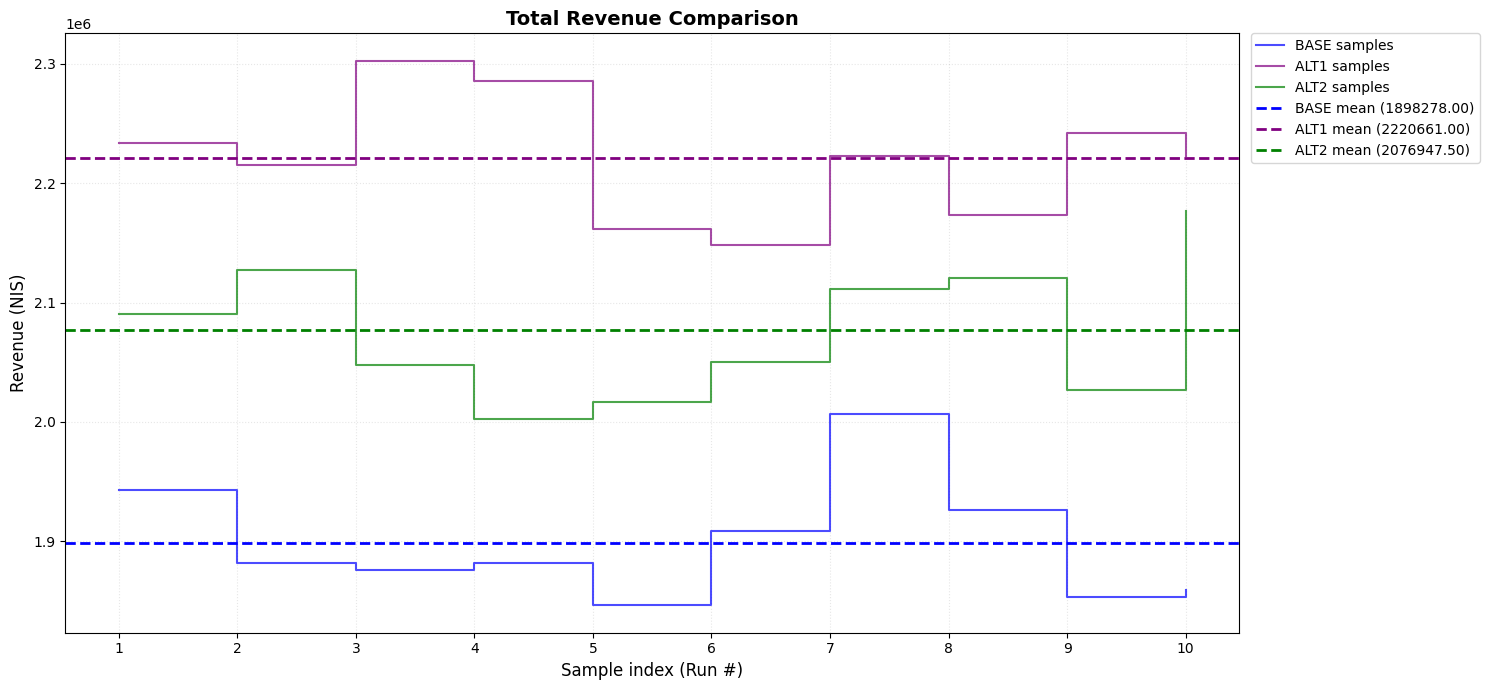

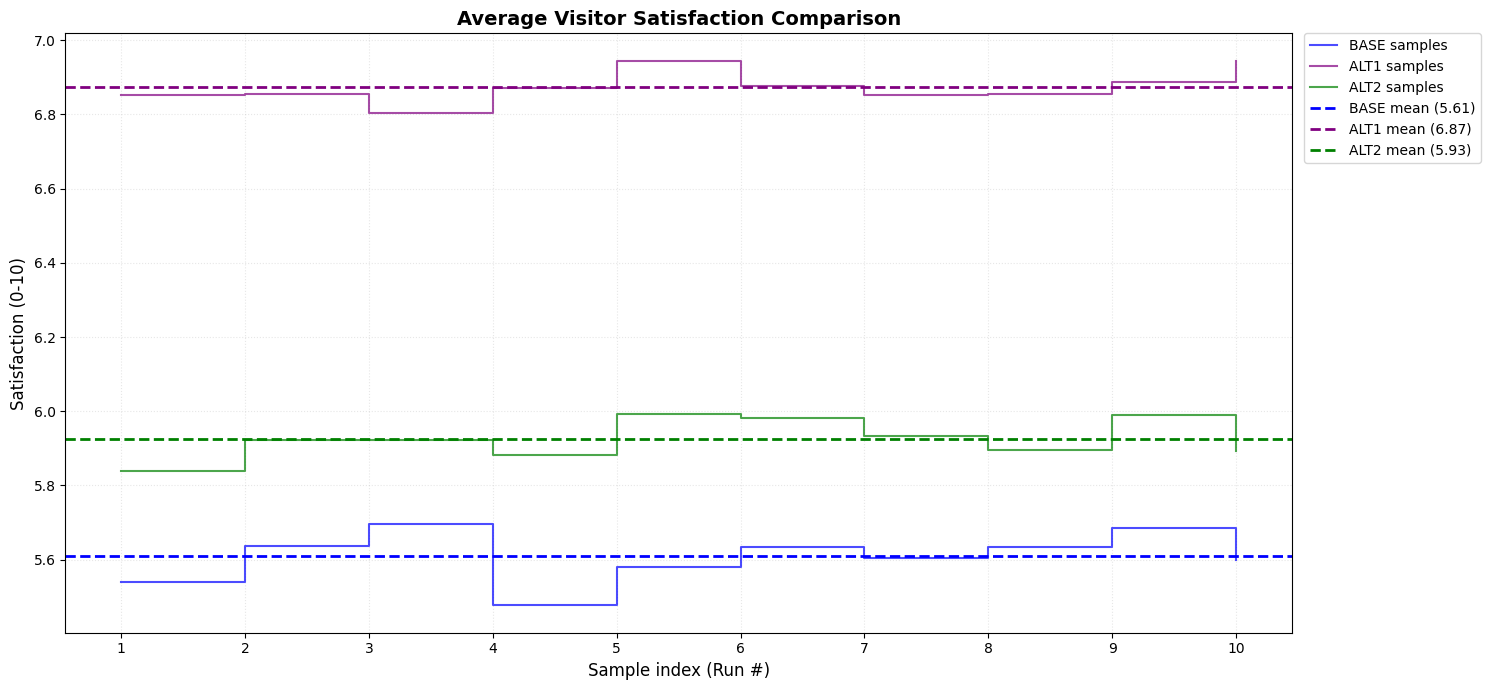

In [ ]:
# ============================================================================
#  גרפים: השוואת תוצאות ההרצות בין התרחישים
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np


def plot_step_comparison(metric_dict, title, ylabel):
    """
    גרף מדרגות (step plot) המשווה את ערך המדד בכל הרצה בין שלושת התרחישים,
    יחד עם קווי ממוצע אופקיים לכל תרחיש.
    """
    base_vals = np.array(metric_dict["base"], dtype=float)
    alt1_vals = np.array(metric_dict["alt1"], dtype=float)
    alt2_vals = np.array(metric_dict["alt2"], dtype=float)

    n = len(base_vals)
    x = range(1, n + 1)

    base_mean = base_vals.mean()
    alt1_mean = alt1_vals.mean()
    alt2_mean = alt2_vals.mean()

    plt.figure(figsize=(15, 7))

    plt.step(x, base_vals, where="post", label="BASE samples", color='blue', alpha=0.7, linewidth=1.5)
    plt.step(x, alt1_vals, where="post", label="ALT1 samples", color='purple', alpha=0.7, linewidth=1.5)
    plt.step(x, alt2_vals, where="post", label="ALT2 samples", color='green', alpha=0.7, linewidth=1.5)

    plt.axhline(base_mean, color='blue', linestyle="--", linewidth=2, label=f"BASE mean ({base_mean:.2f})")
    plt.axhline(alt1_mean, color='purple', linestyle="--", linewidth=2, label=f"ALT1 mean ({alt1_mean:.2f})")
    plt.axhline(alt2_mean, color='green', linestyle="--", linewidth=2, label=f"ALT2 mean ({alt2_mean:.2f})")

    plt.xlabel("Sample index (Run #)", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
    plt.grid(axis='both', alpha=0.3, linestyle=':')
    plt.xticks(range(1, n + 1, max(1, n // 10)))

    plt.tight_layout()
    plt.show()


total_revenue_data = {
    "base": final_results["Base"]["Total Revenue"].tolist(),
    "alt1": final_results["Alt1"]["Total Revenue"].tolist(),
    "alt2": final_results["Alt2"]["Total Revenue"].tolist(),
}

avg_satisfaction_data = {
    "base": final_results["Base"]["Avg Satisfaction"].tolist(),
    "alt1": final_results["Alt1"]["Avg Satisfaction"].tolist(),
    "alt2": final_results["Alt2"]["Avg Satisfaction"].tolist(),
}

plot_step_comparison(total_revenue_data, "Total Revenue Comparison", "Revenue (NIS)")
plot_step_comparison(avg_satisfaction_data, "Average Visitor Satisfaction Comparison", "Satisfaction (0-10)")


<div dir="rtl">

## מסקנות והמלצה

לאחר ביצוע ההרצות הנדרשות וניתוח התוצאות בהתאם למתודולוגיה הסטטיסטית שהוגדרה (רמת ביטחון כוללת של 90% ושימוש בתיקון בונפרוני עבור 6 השוואות), ניתן להסיק כי שתי החלופות שנבחנו משפרות את ביצועי המערכת ביחס למצב הבסיס.

ממצאי ההשוואה מצביעים על כך שגם חלופה 1 וגם חלופה 2 הובילו לשיפור מובהק סטטיסטית בשני מדדי ההערכה שנבחרו – הכנסה כוללת ושביעות רצון ממוצעת של המבקרים – תוך עמידה במסגרת התקציב שהוגדרה מראש. כלומר, בשתי החלופות התקבלה תמורה גבוהה יותר ביחס למצב הקיים, ללא חריגה ממגבלת התקציב של 1,000,000 ₪.

עם זאת, בהשוואה ישירה בין שתי החלופות התקבל יתרון מובהק לטובת חלופה 1. התוצאות הראו כי חלופה זו הניבה בממוצע הכנסה גבוהה יותר בכ־143,714 ₪ לעומת חלופה 2, וכן שיפור ממוצע של כ־0.95 נקודות במדד שביעות הרצון של המבקרים.

בהתבסס על ממצאים אלו, ההמלצה היא לאמץ את **חלופה 1**, הכוללת הטבת מבקרים, סריקת כרטיסים אוטומטית בכניסה ותגבור עמדות הצילום ואמני ציורי הגוף.

חלופה זו מספקת את האיזון הטוב ביותר בין השקעה לתוצאה, ומשיגה את השיפור הגבוה ביותר הן במדדי ההכנסה והן במדדי חוויית המבקר, תוך שמירה על מסגרת התקציב שהוגדרה לפרויקט.

</div>